# Module 3 (Week 3): Estimation and Hypothesis Testing

**Week 3:** Module 3 - Estimation and Hypothesis Testing

**Topics Covered:**
- Interval Estimation of the Mean (σ known and unknown)
- Confidence Intervals
- Determining Sample Size
- Hypothesis Testing Framework
- Type I and Type II Errors
- p-values and Significance Levels
- One-Sample Tests (Z-test and T-test)

---

## Module Introduction

In this module, we move beyond descriptive statistics and probability to focus on **estimation** and **hypothesis testing**. These are the tools that allow us to make inferences about populations using sample data.

### Learning Objectives:

By the end of this module, you will be able to:

1. **Perform interval estimation** for a population mean when the population variance is either known or unknown
2. **Determine the right sample size** for achieving a desired precision in estimation
3. **Formulate and conduct hypothesis tests** using a systematic framework
4. **Interpret p-values** and make decisions about null and alternative hypotheses
5. **Choose between Z-test and T-test** based on the available information

### Why This Matters:

Whether you're constructing a confidence interval or conducting a hypothesis test, these methods give us the power to draw meaningful conclusions from data. This is the foundation of inferential statistics!

---

In [ ]:
# Setup: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup Complete! All libraries loaded successfully.")

Setup Complete! All libraries loaded successfully.


---

## Section 1: Understanding Confidence Intervals - The Logic

### From Point Estimates to Interval Estimates

When we estimate a population parameter (like the mean), a **point estimate** gives us a single number. For example, if we measure the average height of a sample of students and get 170 cm, that's our point estimate.

But here's the problem: **If we take a different sample, we'll get a different sample mean!**

This natural, chance-driven variation from sample to sample means our point estimate will never be perfectly correct. The difference between our sample mean and the true population mean is called **sampling error**.

### What is a Confidence Interval?

A **confidence interval (CI)** provides a **range of plausible values** for the population parameter. It gives us a way to quantify our uncertainty.

**Formula:** Point Estimate ± Margin of Error

### What Does "95% Confidence" Really Mean?

A 95% confidence interval means:
- If we were to take many samples and construct an interval for each one
- 95% of those intervals would contain the true population parameter
- It's a statement about the **long-run success rate of the method**, not about a single interval

### Real-World Example

Think of a financial analyst predicting earnings per share:

- **Point estimate:** \$1.50 per share (might not be accurate)

- **Interval estimate:** Between \$1.40 and \$1.60 per share (more credible!)

The interval has a higher chance of containing the true value.

Let's visualize this concept with a simulation!

---

True Population Mean (unknown in practice): 99.97

Drawing 100 samples of size 30...
Constructing 95.0% confidence intervals for each...



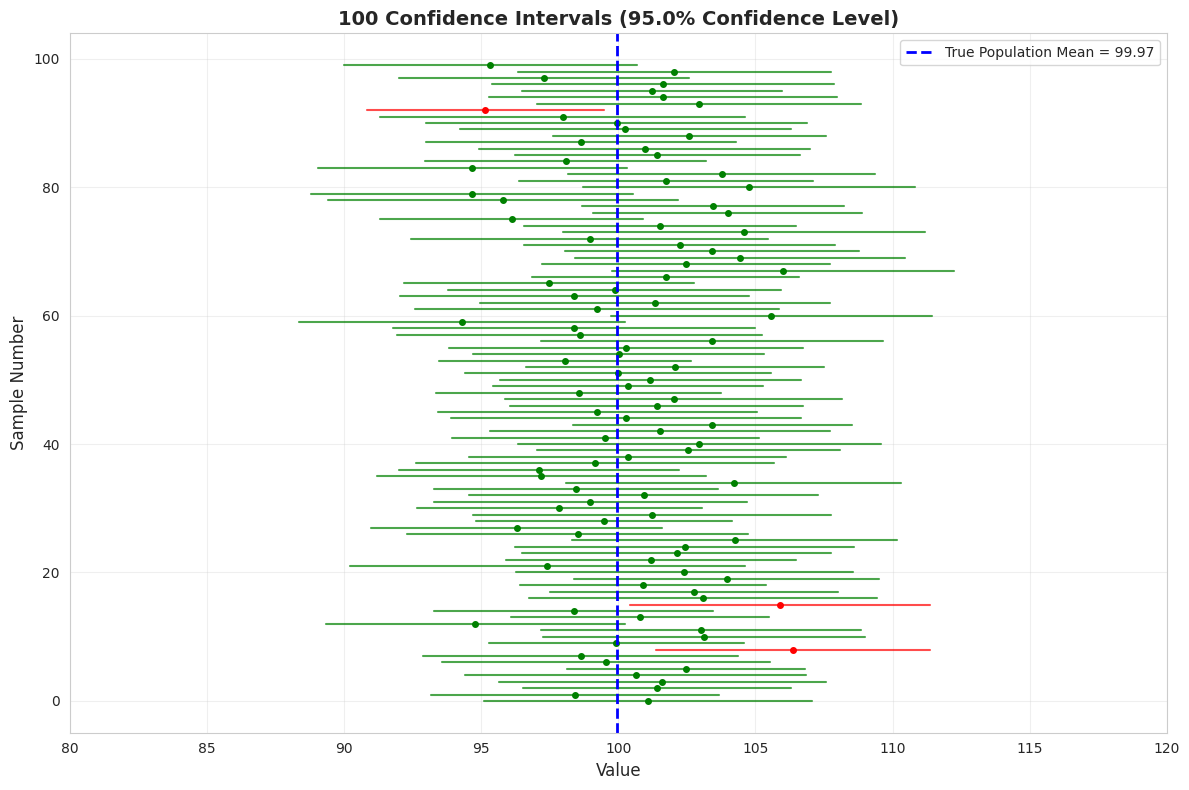


RESULTS:
Out of 100 intervals:
  - 97 intervals (GREEN) captured the true mean
  - 3 intervals (RED) missed the true mean
  - Success rate: 97.0%

Expected success rate: 95.0%


IMPORTANT INSIGHT:
Notice the red intervals - by chance, some samples produce
intervals that MISS the true mean. This is what '95% confidence'
means: it's about the long-run success rate of the method!


In [ ]:
# Simulation: Understanding What Confidence Intervals Mean

# Define our population (true but unknown to us in practice)
population = np.random.normal(loc=100, scale=15, size=10000)
true_mean = np.mean(population)  # This is what we're trying to capture

# Settings for our simulation
num_samples = 100
sample_size = 30
confidence_level = 0.95
captured_count = 0

# Store results for plotting
sample_means = []
lower_bounds = []
upper_bounds = []
colors = []

print(f"True Population Mean (unknown in practice): {true_mean:.2f}")
print(f"\nDrawing {num_samples} samples of size {sample_size}...")
print(f"Constructing {confidence_level*100}% confidence intervals for each...\n")

for i in range(num_samples):
    # 1. Take a random sample
    sample = np.random.choice(population, size=sample_size, replace=False)
    sample_mean = np.mean(sample)
    sample_std = np.std(sample, ddof=1)

    # 2. Calculate standard error
    sem = sample_std / np.sqrt(sample_size)

    # 3. Calculate confidence interval using t-distribution
    ci = stats.t.interval(confidence_level, df=sample_size-1,
                         loc=sample_mean, scale=sem)

    # 4. Check if interval captures the true mean
    if ci[0] <= true_mean <= ci[1]:
        captured_count += 1
        colors.append('green')
    else:
        colors.append('red')

    sample_means.append(sample_mean)
    lower_bounds.append(ci[0])
    upper_bounds.append(ci[1])

# Visualize the results
plt.figure(figsize=(12, 8))

for i in range(num_samples):
    # Plot confidence interval as horizontal line
    plt.plot([lower_bounds[i], upper_bounds[i]], [i, i],
            color=colors[i], linewidth=1.5, alpha=0.7)
    # Plot sample mean as point
    plt.plot(sample_means[i], i, 'o', color=colors[i], markersize=4)

# Add vertical line for true population mean
plt.axvline(true_mean, color='blue', linestyle='--', linewidth=2,
           label=f'True Population Mean = {true_mean:.2f}')

plt.xlabel('Value', fontsize=12)
plt.ylabel('Sample Number', fontsize=12)
plt.title(f'{num_samples} Confidence Intervals ({confidence_level*100}% Confidence Level)',
         fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([80,120])
plt.tight_layout()
plt.show()

# Print results
print(f"\n{'='*60}")
print(f"RESULTS:")
print(f"{'='*60}")
print(f"Out of {num_samples} intervals:")
print(f"  - {captured_count} intervals (GREEN) captured the true mean")
print(f"  - {num_samples - captured_count} intervals (RED) missed the true mean")
print(f"  - Success rate: {captured_count/num_samples*100:.1f}%")
print(f"\nExpected success rate: {confidence_level*100}%")
print(f"\n{'='*60}")
print("\nIMPORTANT INSIGHT:")
print("Notice the red intervals - by chance, some samples produce")
print("intervals that MISS the true mean. This is what '95% confidence'")
print("means: it's about the long-run success rate of the method!")
print(f"{'='*60}")

### 🔍 TO DO #1: Experiment with Confidence Levels

Modify the simulation above to see how different confidence levels affect the intervals:

**Tasks:**
1. Change `confidence_level = 0.95` to `0.90` (90% confidence)
   - What happens to the number of intervals that capture the true mean?
   - Do the intervals become wider or narrower?

2. Try `confidence_level = 0.99` (99% confidence)
   - How does this affect the interval width?
   - How many intervals now capture the true mean?

3. Experiment with sample size:
   - Change `sample_size = 30` to `10` (smaller samples)
   - Then try `sample_size = 100` (larger samples)
   - How does sample size affect interval width?

**Questions to think about:**
- What's the trade-off between confidence level and interval width?
- Why might we not always use 99% confidence intervals?
- What happens when sample size increases?

---

---

## Section 2: Interval Estimation (σ known - Z-interval)

### When Do We Use the Z-interval?

We use the **Z-interval** when the population standard deviation (σ) is **known**. This is an ideal but rare situation in practice.

**Real-world example:** A manufacturing setting where a machine has been producing parts for years, and its output variability is extremely well documented.

### Formula for Confidence Interval (σ known)

$$\bar{x} \pm Z_{\alpha/2} \times \frac{\sigma}{\sqrt{n}}$$

Where:
- $\bar{x}$ = sample mean (point estimate)
- $Z_{\alpha/2}$ = critical value from standard normal distribution
- $\sigma$ = population standard deviation (known)
- $n$ = sample size
- $\frac{\sigma}{\sqrt{n}}$ = standard error (SE)

### Understanding the Components

1. **Point Estimate ($\bar{x}$):** Our best guess from the sample
2. **Critical Value ($Z_{\alpha/2}$):** Determines confidence level
   - 90% confidence: Z = 1.645
   - 95% confidence: Z = 1.96
   - 99% confidence: Z = 2.576
3. **Standard Error (SE):** Measures variability of sample means
4. **Margin of Error:** $Z_{\alpha/2} \times SE$

---

SCENARIO: Light Bulb Lifespan Estimation

Given Information:
  Population standard deviation (σ): 100 hours
  Sample size (n): 40 bulbs
  Sample mean (x̄): 780 hours
  Confidence level: 95.0%

Step 1: Find Critical Z-value
  α = 1 - 0.95 = 0.050000000000000044
  Z_0.025000000000000022 = Z_0.025 = 1.960
  (Commonly known as 1.96 for 95% confidence)

Step 2: Calculate Standard Error
  SE = σ / √n
  SE = 100 / √40
  SE = 15.811

Step 3: Calculate Margin of Error
  ME = Z_0.025000000000000022 × SE
  ME = 1.960 × 15.811
  ME = 30.990

Step 4: Construct Confidence Interval
  CI = x̄ ± ME
  CI = 780 ± 30.99
  CI = (749.01, 810.99)

INTERPRETATION:
We are 95.0% confident that the true average
lifespan of the light bulbs is between 749.01 and 810.99 hours.


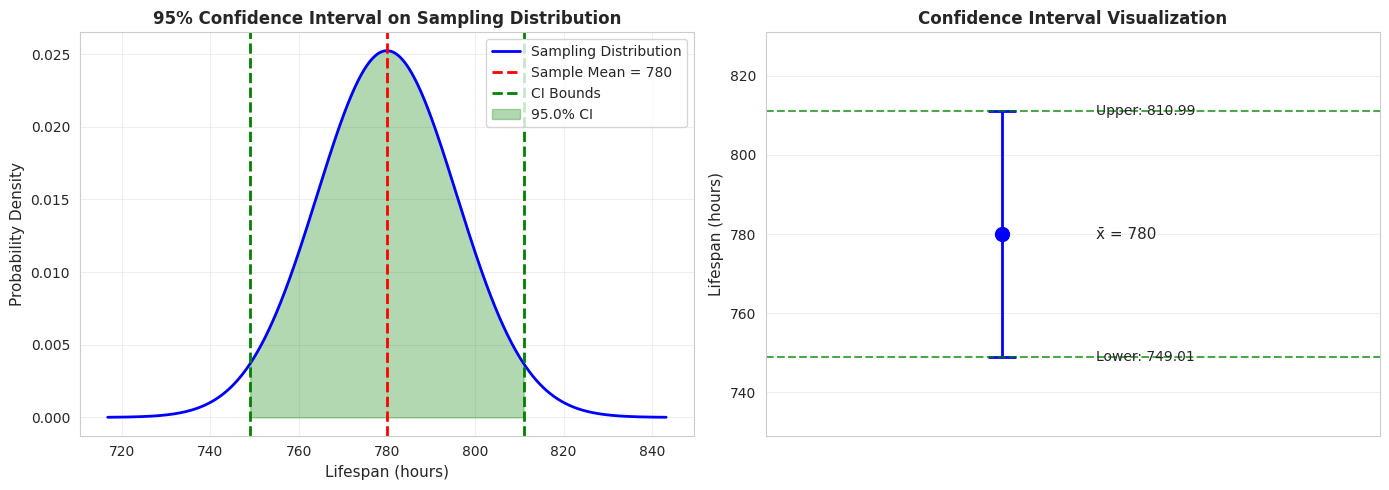

In [ ]:
# Example: Light Bulb Lifespan

print("="*70)
print("SCENARIO: Light Bulb Lifespan Estimation")
print("="*70)
print()

# Given information
sigma = 100  # Population standard deviation (known from manufacturer)
n = 40       # Sample size
x_bar = 780  # Sample mean lifespan (hours)
confidence_level = 0.95

print("Given Information:")
print(f"  Population standard deviation (σ): {sigma} hours")
print(f"  Sample size (n): {n} bulbs")
print(f"  Sample mean (x̄): {x_bar} hours")
print(f"  Confidence level: {confidence_level*100}%")
print()

# Step 1: Find critical Z-value
alpha = 1 - confidence_level
z_critical = stats.norm.ppf(1 - alpha/2)

print("Step 1: Find Critical Z-value")
print(f"  α = 1 - {confidence_level} = {alpha}")
print(f"  Z_{alpha/2} = Z_{alpha/2:.3f} = {z_critical:.3f}")
print(f"  (Commonly known as 1.96 for 95% confidence)")
print()

# Step 2: Calculate Standard Error
standard_error = sigma / math.sqrt(n)

print("Step 2: Calculate Standard Error")
print(f"  SE = σ / √n")
print(f"  SE = {sigma} / √{n}")
print(f"  SE = {standard_error:.3f}")
print()

# Step 3: Calculate Margin of Error
margin_of_error = z_critical * standard_error

print("Step 3: Calculate Margin of Error")
print(f"  ME = Z_{alpha/2} × SE")
print(f"  ME = {z_critical:.3f} × {standard_error:.3f}")
print(f"  ME = {margin_of_error:.3f}")
print()

# Step 4: Construct Confidence Interval
ci_lower = x_bar - margin_of_error
ci_upper = x_bar + margin_of_error

print("Step 4: Construct Confidence Interval")
print(f"  CI = x̄ ± ME")
print(f"  CI = {x_bar} ± {margin_of_error:.2f}")
print(f"  CI = ({ci_lower:.2f}, {ci_upper:.2f})")
print()

print("="*70)
print("INTERPRETATION:")
print("="*70)
print(f"We are {confidence_level*100}% confident that the true average")
print(f"lifespan of the light bulbs is between {ci_lower:.2f} and {ci_upper:.2f} hours.")
print("="*70)

# Visualize the confidence interval
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Normal distribution with shaded area
x_range = np.linspace(x_bar - 4*standard_error, x_bar + 4*standard_error, 1000)
y = stats.norm.pdf(x_range, x_bar, standard_error)

ax1.plot(x_range, y, 'b-', linewidth=2, label='Sampling Distribution')
ax1.axvline(x_bar, color='red', linestyle='--', linewidth=2, label=f'Sample Mean = {x_bar}')
ax1.axvline(ci_lower, color='green', linestyle='--', linewidth=2, label='CI Bounds')
ax1.axvline(ci_upper, color='green', linestyle='--', linewidth=2)
ax1.fill_between(x_range, y, where=(x_range >= ci_lower) & (x_range <= ci_upper),
                alpha=0.3, color='green', label=f'{confidence_level*100}% CI')
ax1.set_xlabel('Lifespan (hours)', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('95% Confidence Interval on Sampling Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Confidence interval visualization
ax2.errorbar(1, x_bar, yerr=margin_of_error, fmt='o', markersize=10,
            capsize=10, capthick=2, color='blue', elinewidth=2)
ax2.axhline(ci_lower, color='green', linestyle='--', alpha=0.7)
ax2.axhline(ci_upper, color='green', linestyle='--', alpha=0.7)
ax2.text(1.2, x_bar, f'x̄ = {x_bar}', fontsize=11, va='center')
ax2.text(1.2, ci_lower, f'Lower: {ci_lower:.2f}', fontsize=10, va='center')
ax2.text(1.2, ci_upper, f'Upper: {ci_upper:.2f}', fontsize=10, va='center')
ax2.set_xlim(0.5, 1.8)
ax2.set_ylim(ci_lower - 20, ci_upper + 20)
ax2.set_ylabel('Lifespan (hours)', fontsize=11)
ax2.set_title('Confidence Interval Visualization', fontsize=12, fontweight='bold')
ax2.set_xticks([])
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 🔍 TO DO #2: Calculate Z-intervals for Different Scenarios

Modify the code above to calculate confidence intervals for these scenarios:

**Scenario A: Battery Life**
- Population std dev (σ): 50 hours
- Sample size (n): 25 batteries
- Sample mean (x̄): 500 hours
- Confidence level: 90%

**Scenario B: Product Weights**
- Population std dev (σ): 5 grams
- Sample size (n): 60 products
- Sample mean (x̄): 250 grams
- Confidence level: 99%

**Tasks:**
1. Calculate the confidence interval for each scenario
2. Compare the width of the intervals - which is wider and why?
3. What happens if you increase the sample size to 100 in Scenario A?

---

---

## Section 3: Interval Estimation (σ unknown - T-interval)

### The Practical Reality

In most real-world scenarios, the population standard deviation (σ) is **unknown**. If we don't know the population mean, it's highly unlikely we know its standard deviation!

### Solution: Use Sample Standard Deviation (s)

When σ is unknown, we:
1. Estimate it using the sample standard deviation (s)
2. Use the **Student's t-distribution** instead of the normal distribution

### Why the t-distribution?

The t-distribution accounts for the extra uncertainty introduced by estimating σ with s. It has:
- **Heavier tails** than the normal distribution
- Shape depends on **degrees of freedom (df = n - 1)**
- Approaches normal distribution as sample size increases

### Formula for Confidence Interval (σ unknown)

$$\bar{x} \pm t_{\alpha/2, df} \times \frac{s}{\sqrt{n}}$$

Where:
- $\bar{x}$ = sample mean
- $t_{\alpha/2, df}$ = critical value from t-distribution with df = n - 1
- $s$ = sample standard deviation
- $n$ = sample size

### Key Difference from Z-interval

| Aspect | Z-interval (σ known) | T-interval (σ unknown) |
|--------|---------------------|----------------------|
| Population σ | Known | Unknown |
| Sample statistic | Use σ | Use s |
| Distribution | Standard Normal (Z) | Student's t |
| Critical value | Depends on confidence level only | Depends on confidence level AND degrees of freedom |
| Interval width | Narrower | Wider (due to extra uncertainty) |

---

Comparing Z-distribution and T-distribution



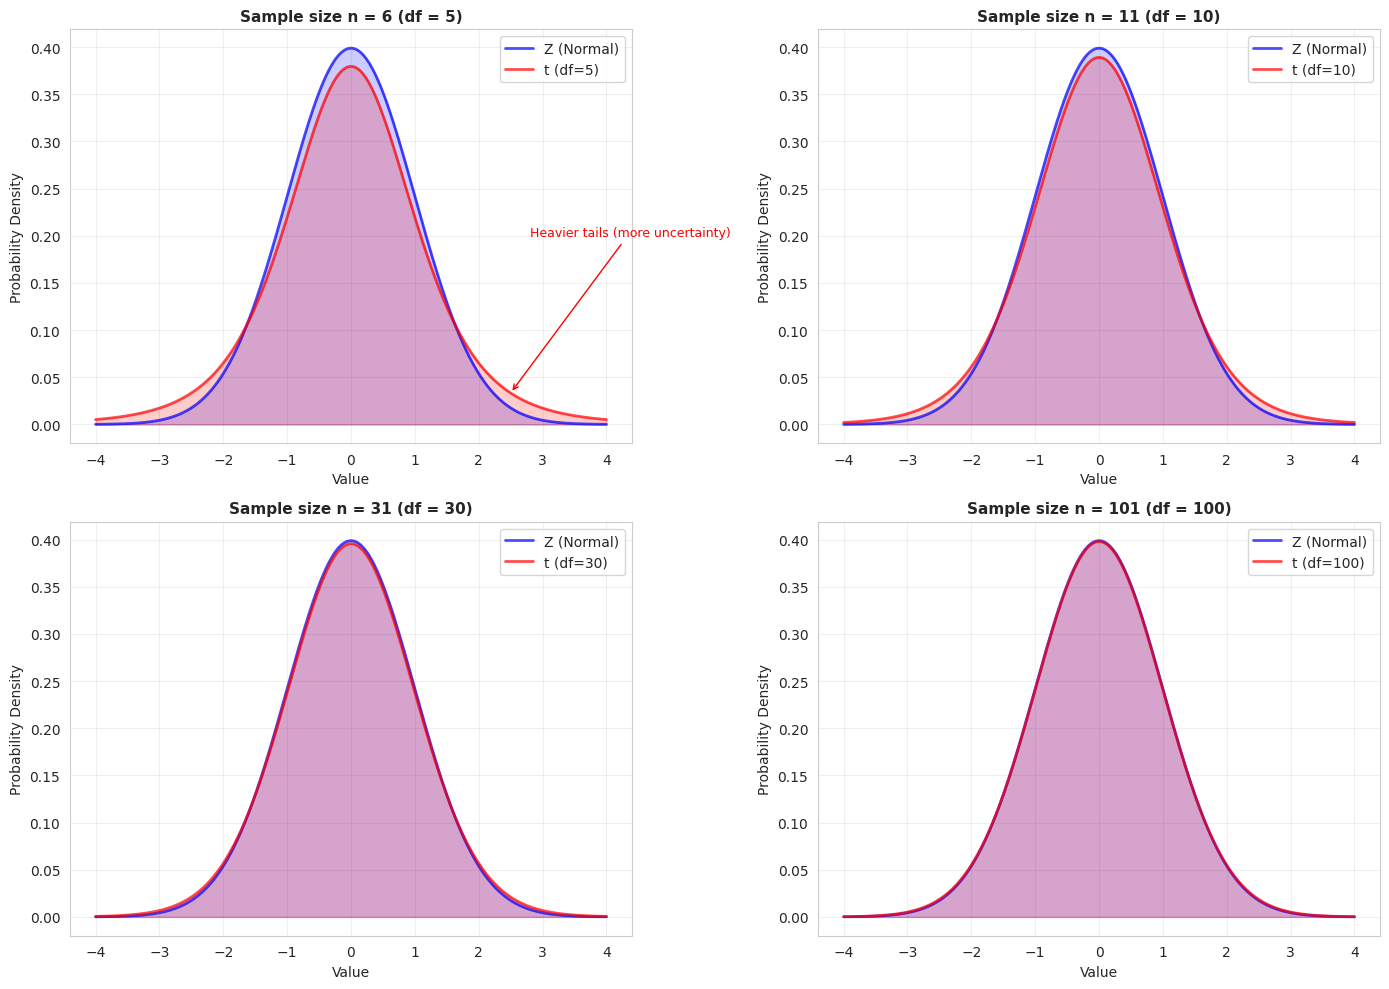

KEY OBSERVATIONS:
----------------------------------------------------------------------
1. With small sample sizes (df = 5):
   - t-distribution has much heavier tails
   - More probability in the extremes
   - Results in wider confidence intervals

2. As sample size increases (df increases):
   - t-distribution becomes more like normal distribution
   - At df ≈ 30, they are almost identical
   - At df = 100, practically indistinguishable

3. Why does this matter?
   - Small samples: Use t-distribution (conservative)
   - Large samples: Z or t give similar results
   - Always safe to use t when σ is unknown


In [ ]:
# Visualizing Z-distribution vs T-distribution

print("="*70)
print("Comparing Z-distribution and T-distribution")
print("="*70)
print()

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Different degrees of freedom
df_values = [5, 10, 30, 100]
x = np.linspace(-4, 4, 1000)

for idx, df in enumerate(df_values):
    ax = axes[idx // 2, idx % 2]

    # Standard normal (Z)
    y_z = stats.norm.pdf(x, 0, 1)
    # t-distribution
    y_t = stats.t.pdf(x, df)

    ax.plot(x, y_z, 'b-', linewidth=2, label='Z (Normal)', alpha=0.7)
    ax.plot(x, y_t, 'r-', linewidth=2, label=f't (df={df})', alpha=0.7)
    ax.fill_between(x, y_z, alpha=0.2, color='blue')
    ax.fill_between(x, y_t, alpha=0.2, color='red')

    ax.set_title(f'Sample size n = {df + 1} (df = {df})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Probability Density', fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add annotation about tail heaviness
    if df == 5:
        ax.annotate('Heavier tails (more uncertainty)',
                   xy=(2.5, stats.t.pdf(2.5, df)),
                   xytext=(2.8, 0.2),
                   arrowprops=dict(arrowstyle='->', color='red'),
                   fontsize=9, color='red')

plt.tight_layout()
plt.show()

print("KEY OBSERVATIONS:")
print("-" * 70)
print("1. With small sample sizes (df = 5):")
print("   - t-distribution has much heavier tails")
print("   - More probability in the extremes")
print("   - Results in wider confidence intervals")
print()
print("2. As sample size increases (df increases):")
print("   - t-distribution becomes more like normal distribution")
print("   - At df ≈ 30, they are almost identical")
print("   - At df = 100, practically indistinguishable")
print()
print("3. Why does this matter?")
print("   - Small samples: Use t-distribution (conservative)")
print("   - Large samples: Z or t give similar results")
print("   - Always safe to use t when σ is unknown")
print("=" * 70)

SCENARIO: Estimating Average Student Height

Sample Data:
  Sample size (n): 20 students
  Sample mean (x̄): 170.80 cm
  Sample std dev (s): 2.95 cm
  Degrees of freedom (df): 19
  Confidence level: 95.0%

Step 1: Find Critical t-value
  α = 0.050000000000000044
  t_0.025000000000000022,19 = 2.093
  (Note: This is larger than Z = 1.96 due to small sample size)

Step 2: Calculate Standard Error
  SE = s / √n
  SE = 2.95 / √20
  SE = 0.659

Step 3: Calculate Margin of Error
  ME = t_0.025000000000000022,19 × SE
  ME = 2.093 × 0.659
  ME = 1.380

Step 4: Construct Confidence Interval
  CI = x̄ ± ME
  CI = 170.80 ± 1.38
  CI = (169.42, 172.18)

COMPARISON: What if we incorrectly used Z-interval?
  Z-interval (incorrect): (169.51, 172.09)
  T-interval (correct):   (169.42, 172.18)
  Difference in width: 0.18 cm

INTERPRETATION:
We are 95.0% confident that the true average
height of the student population is between 169.42 and 172.18 cm.

Verification using scipy: (169.42, 172.18)


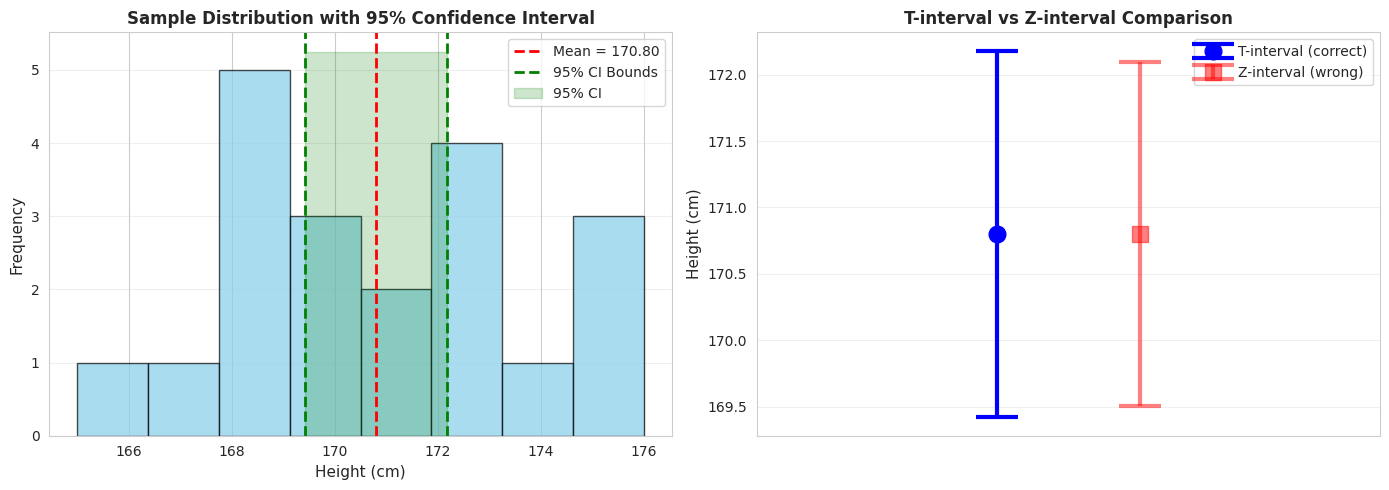

In [ ]:
# Example: Student Heights (σ unknown)

print("="*70)
print("SCENARIO: Estimating Average Student Height")
print("="*70)
print()

# Sample data: Heights of 20 students (in cm)
heights = np.array([170, 165, 172, 168, 175, 169, 171, 173, 167, 174,
                    176, 168, 170, 172, 169, 171, 173, 168, 175, 170])

n = len(heights)
x_bar = np.mean(heights)
s = np.std(heights, ddof=1)  # Sample standard deviation
confidence_level = 0.95
df = n - 1

print("Sample Data:")
print(f"  Sample size (n): {n} students")
print(f"  Sample mean (x̄): {x_bar:.2f} cm")
print(f"  Sample std dev (s): {s:.2f} cm")
print(f"  Degrees of freedom (df): {df}")
print(f"  Confidence level: {confidence_level*100}%")
print()

# Step 1: Find critical t-value
alpha = 1 - confidence_level
t_critical = stats.t.ppf(1 - alpha/2, df=df)

print("Step 1: Find Critical t-value")
print(f"  α = {alpha}")
print(f"  t_{alpha/2},{df} = {t_critical:.3f}")
print(f"  (Note: This is larger than Z = 1.96 due to small sample size)")
print()

# Step 2: Calculate Standard Error
standard_error = s / math.sqrt(n)

print("Step 2: Calculate Standard Error")
print(f"  SE = s / √n")
print(f"  SE = {s:.2f} / √{n}")
print(f"  SE = {standard_error:.3f}")
print()

# Step 3: Calculate Margin of Error
margin_of_error = t_critical * standard_error

print("Step 3: Calculate Margin of Error")
print(f"  ME = t_{alpha/2},{df} × SE")
print(f"  ME = {t_critical:.3f} × {standard_error:.3f}")
print(f"  ME = {margin_of_error:.3f}")
print()

# Step 4: Construct Confidence Interval
ci_lower = x_bar - margin_of_error
ci_upper = x_bar + margin_of_error

print("Step 4: Construct Confidence Interval")
print(f"  CI = x̄ ± ME")
print(f"  CI = {x_bar:.2f} ± {margin_of_error:.2f}")
print(f"  CI = ({ci_lower:.2f}, {ci_upper:.2f})")
print()

# Compare with Z-interval (if we incorrectly used it)
z_critical = 1.96
z_margin = z_critical * standard_error
z_ci_lower = x_bar - z_margin
z_ci_upper = x_bar + z_margin

print("COMPARISON: What if we incorrectly used Z-interval?")
print(f"  Z-interval (incorrect): ({z_ci_lower:.2f}, {z_ci_upper:.2f})")
print(f"  T-interval (correct):   ({ci_lower:.2f}, {ci_upper:.2f})")
print(f"  Difference in width: {(ci_upper-ci_lower) - (z_ci_upper-z_ci_lower):.2f} cm")
print()

print("="*70)
print("INTERPRETATION:")
print("="*70)
print(f"We are {confidence_level*100}% confident that the true average")
print(f"height of the student population is between {ci_lower:.2f} and {ci_upper:.2f} cm.")
print("="*70)

# Verify using scipy function
ci_scipy = stats.t.interval(confidence_level, df=df, loc=x_bar, scale=stats.sem(heights))
print()
print(f"Verification using scipy: ({ci_scipy[0]:.2f}, {ci_scipy[1]:.2f})")

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram with CI
ax1.hist(heights, bins=8, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(x_bar, color='red', linestyle='--', linewidth=2, label=f'Mean = {x_bar:.2f}')
ax1.axvline(ci_lower, color='green', linestyle='--', linewidth=2, label='95% CI Bounds')
ax1.axvline(ci_upper, color='green', linestyle='--', linewidth=2)
ax1.fill_between([ci_lower, ci_upper], 0, ax1.get_ylim()[1],
                alpha=0.2, color='green', label='95% CI')
ax1.set_xlabel('Height (cm)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Sample Distribution with 95% Confidence Interval', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Right: Confidence interval comparison
ax2.errorbar(1, x_bar, yerr=margin_of_error, fmt='o', markersize=12,
            capsize=15, capthick=3, color='blue', elinewidth=3, label='T-interval (correct)')
ax2.errorbar(1.3, x_bar, yerr=z_margin, fmt='s', markersize=12,
            capsize=15, capthick=3, color='red', elinewidth=3, label='Z-interval (wrong)', alpha=0.5)
ax2.set_xlim(0.5, 1.8)
ax2.set_ylabel('Height (cm)', fontsize=11)
ax2.set_title('T-interval vs Z-interval Comparison', fontsize=12, fontweight='bold')
ax2.set_xticks([])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 🔍 TO DO #3: Practice T-intervals with Different Datasets

**Task 1: Small Sample**
Create a dataset of 15 exam scores and calculate a 90% confidence interval.

```python
exam_scores = np.array([78, 82, 75, 88, 91, 79, 85, 83, 77, 89, 92, 80, 86, 84, 81])
```

**Task 2: Compare Sample Sizes**
Generate two random samples:
- Sample A: n = 10
- Sample B: n = 50

Both from the same population (mean=50, std=10). Calculate 95% CIs for both and compare:
- Which interval is wider?
- How do the critical t-values differ?

**Task 3: Effect of Confidence Level**
Using the heights data above, calculate confidence intervals at:
- 90% confidence
- 95% confidence (already done)
- 99% confidence

Compare the interval widths and explain the pattern you observe.

---

---

## Section 4: Determining Sample Size

### The Critical Question: How Much Data Do We Need?

Before collecting data, we face an important balancing act:

**Too Small Sample:**
- Unreliable results
- Large margin of error
- Low precision

**Too Large Sample:**
- Wastes time and money
- Unnecessary resources
- Diminishing returns

**Goal:** Find the minimum sample size that gives us the precision and confidence we need.

### What Determines Sample Size?

Three key factors drive sample size calculations:

1. **Margin of Error (E):** How precise do we need to be?
   - Smaller E → Larger n needed
   - E appears in denominator, so halving E requires 4× the sample size

2. **Confidence Level:** How certain do we want to be?
   - Higher confidence → Larger critical value → Larger n
   - 99% confidence requires more data than 95%

3. **Population Variability (σ):** How diverse is the population?
   - More variability → Larger n needed
   - Less variability → Smaller n sufficient

### Formula for Required Sample Size

$$n = \left(\frac{Z_{\alpha/2} \cdot \sigma}{E}\right)^2$$

Where:
- $n$ = required sample size
- $Z_{\alpha/2}$ = critical Z-value for desired confidence level
- $\sigma$ = population standard deviation (or estimate)
- $E$ = desired margin of error

**Important:** Always round UP to ensure desired precision!

### What if σ is Unknown?

In practice, σ is often unknown. Solutions:

1. **Pilot Study:** Conduct a small preliminary sample, use its standard deviation
2. **Previous Studies:** Use σ from similar past research
3. **Rule of Thumb:** Estimate σ ≈ (max - min) / 4

---

SCENARIO: Planning a Smartphone Battery Life Study

Study Design Parameters:
  Estimated population std deviation (σ): 2.0 hours
  Desired margin of error (E): 0.5 hours
  Desired confidence level: 99.0%

Step 1: Determine Critical Z-value
  For 99.0% confidence:
  Z_0.0050000000000000044 = 2.576

Step 2: Calculate Required Sample Size
  n = (Z_0.0050000000000000044 × σ / E)²
  n = (2.576 × 2.0 / 0.5)²
  n = 106.16

Step 3: Round Up (Always!)
  Required sample size: 107 smartphones

INTERPRETATION:
To estimate average battery life with:
  - Margin of error: ±0.5 hours
  - Confidence level: 99.0%
We need to test at least 107 smartphones.


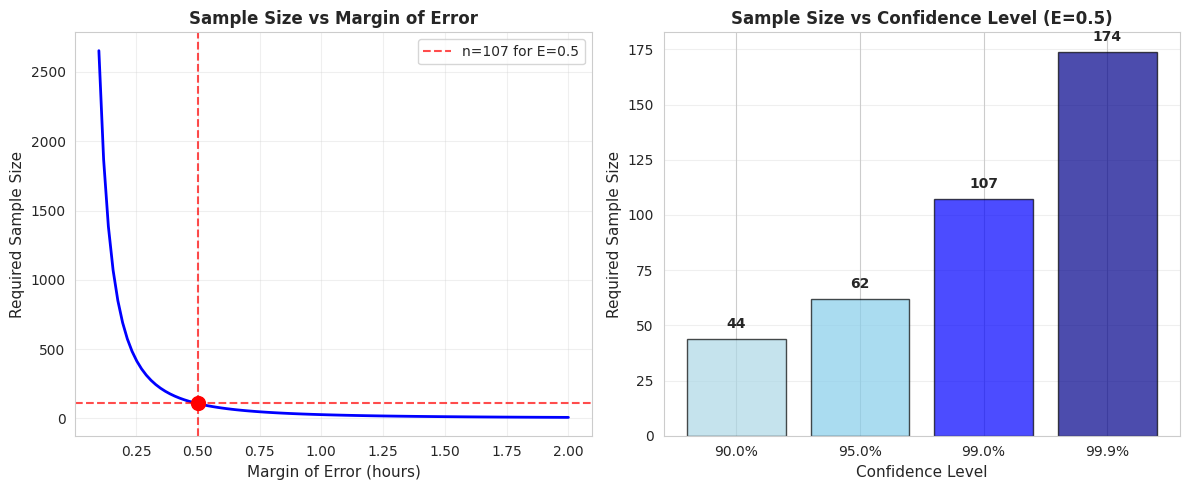


KEY INSIGHTS:
----------------------------------------------------------------------
1. Margin of Error Effect:
   - Halving the margin of error (0.5 → 0.25) requires 4× the sample!
   - This is because n is proportional to 1/E²

2. Confidence Level Effect:
   -  90.0% confidence requires n =  44
   -  95.0% confidence requires n =  62
   -  99.0% confidence requires n = 107
   -  99.9% confidence requires n = 174

3. Trade-offs:
   - More precision (smaller E) = More expensive
   - More confidence = More expensive
   - Must balance cost with required precision


In [ ]:
# Example: Smartphone Battery Life Study

print("="*70)
print("SCENARIO: Planning a Smartphone Battery Life Study")
print("="*70)
print()

# Study parameters
sigma_est = 2.0  # Estimated population std dev (hours) from similar models
ME_desired = 0.5  # Desired margin of error (hours)
confidence_level = 0.99  # We want 99% confidence

print("Study Design Parameters:")
print(f"  Estimated population std deviation (σ): {sigma_est} hours")
print(f"  Desired margin of error (E): {ME_desired} hours")
print(f"  Desired confidence level: {confidence_level*100}%")
print()

# Step 1: Find critical Z-value
alpha = 1 - confidence_level
z_critical = stats.norm.ppf(1 - alpha/2)

print("Step 1: Determine Critical Z-value")
print(f"  For {confidence_level*100}% confidence:")
print(f"  Z_{alpha/2} = {z_critical:.3f}")
print()

# Step 2: Calculate required sample size
n_required = ((z_critical * sigma_est) / ME_desired)**2

print("Step 2: Calculate Required Sample Size")
print(f"  n = (Z_{alpha/2} × σ / E)²")
print(f"  n = ({z_critical:.3f} × {sigma_est} / {ME_desired})²")
print(f"  n = {n_required:.2f}")
print()

# Always round UP
n_final = math.ceil(n_required)

print("Step 3: Round Up (Always!)")
print(f"  Required sample size: {n_final} smartphones")
print()

print("="*70)
print("INTERPRETATION:")
print("="*70)
print(f"To estimate average battery life with:")
print(f"  - Margin of error: ±{ME_desired} hours")
print(f"  - Confidence level: {confidence_level*100}%")
print(f"We need to test at least {n_final} smartphones.")
print("="*70)

# Visualize relationship between margin of error and sample size
margins = np.linspace(0.1, 2.0, 100)
sample_sizes = ((z_critical * sigma_est) / margins)**2

plt.figure(figsize=(12, 5))

# Left plot: Sample size vs Margin of Error
plt.subplot(1, 2, 1)
plt.plot(margins, sample_sizes, 'b-', linewidth=2)
plt.axhline(y=n_final, color='r', linestyle='--', alpha=0.7, label=f'n={n_final} for E={ME_desired}')
plt.axvline(x=ME_desired, color='r', linestyle='--', alpha=0.7)
plt.plot(ME_desired, n_final, 'ro', markersize=10)
plt.xlabel('Margin of Error (hours)', fontsize=11)
plt.ylabel('Required Sample Size', fontsize=11)
plt.title('Sample Size vs Margin of Error', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

# Right plot: Effect of confidence level
plt.subplot(1, 2, 2)
confidence_levels = [0.90, 0.95, 0.99, 0.999]
n_values = []
conf_labels = []

for conf in confidence_levels:
    z = stats.norm.ppf(1 - (1-conf)/2)
    n = math.ceil(((z * sigma_est) / ME_desired)**2)
    n_values.append(n)
    conf_labels.append(f'{conf*100}%')

plt.bar(conf_labels, n_values, color=['lightblue', 'skyblue', 'blue', 'darkblue'],
       edgecolor='black', alpha=0.7)
plt.ylabel('Required Sample Size', fontsize=11)
plt.xlabel('Confidence Level', fontsize=11)
plt.title(f'Sample Size vs Confidence Level (E={ME_desired})', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

for i, (conf, n) in enumerate(zip(conf_labels, n_values)):
    plt.text(i, n + 5, str(n), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print()
print("KEY INSIGHTS:")
print("-" * 70)
print("1. Margin of Error Effect:")
print("   - Halving the margin of error (0.5 → 0.25) requires 4× the sample!")
print("   - This is because n is proportional to 1/E²")
print()
print("2. Confidence Level Effect:")
for conf, n in zip(confidence_levels, n_values):
    print(f"   - {conf*100:5.1f}% confidence requires n = {n:3d}")
print()
print("3. Trade-offs:")
print("   - More precision (smaller E) = More expensive")
print("   - More confidence = More expensive")
print("   - Must balance cost with required precision")
print("=" * 70)

### 🔍 TO DO #4: Sample Size Calculations Practice

**Scenario A: Quality Control**
A factory wants to estimate the average weight of cereal boxes. From past data, σ ≈ 10 grams.

Calculate required sample size for:
1. E = 2 grams, 95% confidence
2. E = 1 gram, 95% confidence (half the error)
3. E = 2 grams, 99% confidence (higher confidence)

Compare the three sample sizes. What patterns do you notice?

**Scenario B: Customer Satisfaction**
You want to estimate average customer satisfaction score (scale 1-10). You estimate σ ≈ 2.5 based on a pilot study of 20 customers.

Tasks:
1. Calculate n for E = 0.5, 95% confidence
2. What if you want E = 0.3 instead?
3. Create a plot showing n vs E for errors from 0.1 to 1.0

**Scenario C: Estimating σ from Range**
You're planning a study on student study hours per week. You know:
- Minimum likely value: 5 hours
- Maximum likely value: 45 hours

Using the rule of thumb σ ≈ (max - min) / 4:
1. Estimate σ
2. Calculate n for E = 2 hours, 95% confidence
3. Is this reasonable? Could you afford this study?

---

---

## Section 5: The Hypothesis Testing Framework

### From Estimation to Decision-Making

So far, we've learned how to estimate population parameters using confidence intervals. Now we move to **hypothesis testing**, where we make decisions about claims or theories using sample data.

### The Courtroom Analogy

Hypothesis testing works like a criminal trial:

| **Courtroom Trial** | **Hypothesis Testing** |
|---------------------|------------------------|
| **Default Assumption:** Defendant is innocent | **Null Hypothesis (H₀):** No effect, no difference, status quo |
| **Prosecutor's Claim:** Defendant is guilty | **Alternative Hypothesis (H₁ or Hₐ):** What we want to prove |
| **Evidence:** Testimony, forensics | **Data:** Sample statistics |
| **Standard:** "Beyond reasonable doubt" | **Significance Level (α):** Usually 0.05 or 5% |
| **Verdict:** Guilty or Not Guilty | **Decision:** Reject H₀ or Fail to Reject H₀ |

**Key Principle:** The defendant (H₀) is presumed innocent until proven guilty. We only reject H₀ if evidence is strong enough!

### Real-World Example

**Claim:** Average battery life of iPhones is 12 hours.

You suspect it's actually less. After testing a sample of 50 phones:

- **H₀ (Null):** μ = 12 hours (manufacturer's claim)
- **H₁ (Alternative):** μ < 12 hours (your suspicion)

You collect data and conduct a test. If evidence strongly contradicts H₀, you reject it.

### The Four-Step Framework

Every hypothesis test follows these steps:

1. **State the hypotheses** (H₀ and H₁)
2. **Set significance level** (α, typically 0.05)
3. **Calculate test statistic** and p-value
4. **Make decision** and interpret

---

THE HYPOTHESIS TESTING FRAMEWORK

SCENARIO: Pizza Delivery Time
----------------------------------------------------------------------
A pizza shop claims average delivery time is 30 minutes or less.
We suspect it's actually MORE than 30 minutes.

STEP 1: State the Hypotheses
----------------------------------------------------------------------
  H₀ (Null Hypothesis):       μ ≤ 30 minutes
                              (Shop's claim is correct)

  H₁ (Alternative Hypothesis): μ > 30 minutes
                              (Our suspicion - delivery takes longer)

  Note: What we want to PROVE goes in H₁
        Everything else goes in H₀

STEP 2: Set Significance Level (α)
----------------------------------------------------------------------
  α = 0.05 (5%)
  This means we're willing to accept a 5% chance of:
  - Rejecting H₀ when it's actually true (Type I error)
  - Making a 'false alarm'

STEP 3: Collect Data and Calculate Test Statistic
-----------------------------------------------

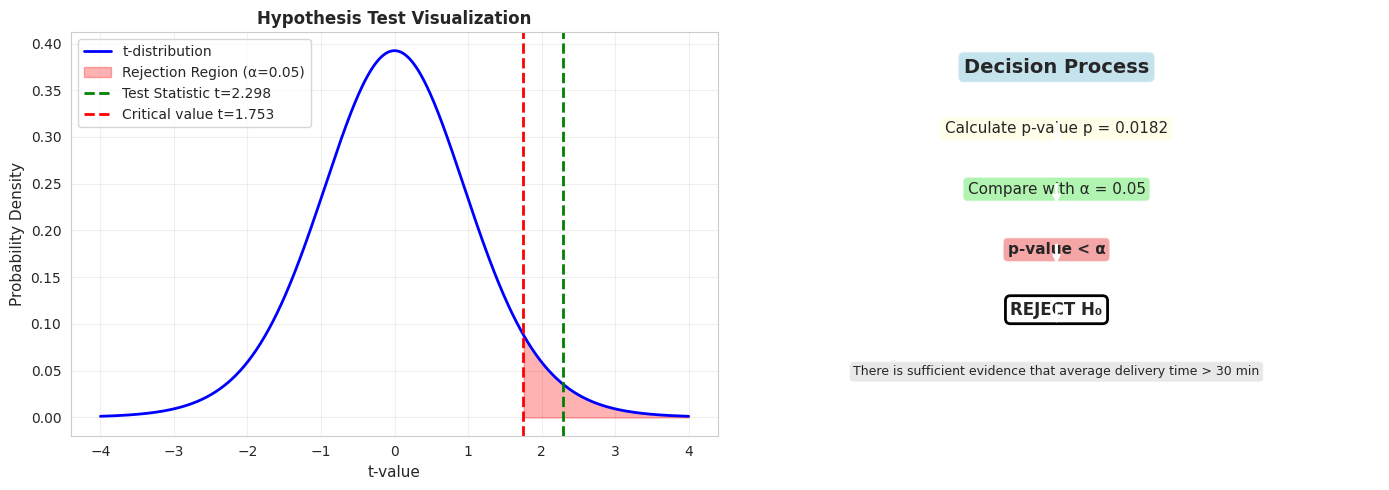

In [ ]:
# Visualization: The Hypothesis Testing Framework

print("="*70)
print("THE HYPOTHESIS TESTING FRAMEWORK")
print("="*70)
print()

# Example scenario
print("SCENARIO: Pizza Delivery Time")
print("-" * 70)
print("A pizza shop claims average delivery time is 30 minutes or less.")
print("We suspect it's actually MORE than 30 minutes.")
print()

# Step 1: State hypotheses
print("STEP 1: State the Hypotheses")
print("-" * 70)
print("  H₀ (Null Hypothesis):       μ ≤ 30 minutes")
print("                              (Shop's claim is correct)")
print()
print("  H₁ (Alternative Hypothesis): μ > 30 minutes")
print("                              (Our suspicion - delivery takes longer)")
print()
print("  Note: What we want to PROVE goes in H₁")
print("        Everything else goes in H₀")
print()

# Step 2: Set significance level
alpha = 0.05
print("STEP 2: Set Significance Level (α)")
print("-" * 70)
print(f"  α = {alpha} (5%)")
print("  This means we're willing to accept a 5% chance of:")
print("  - Rejecting H₀ when it's actually true (Type I error)")
print("  - Making a 'false alarm'")
print()

# Step 3: Collect data and calculate test statistic
# Simulated delivery times (in minutes)
np.random.seed(42)
sample_size = 16
true_mean = 33.5  # Unknown to us, but actually > 30
sample_data = np.random.normal(loc=true_mean, scale=6, size=sample_size)
sample_mean = np.mean(sample_data)
sample_std = np.std(sample_data, ddof=1)

print("STEP 3: Collect Data and Calculate Test Statistic")
print("-" * 70)
print(f"  Sample size (n): {sample_size} deliveries")
print(f"  Sample mean (x̄): {sample_mean:.2f} minutes")
print(f"  Sample std dev (s): {sample_std:.2f} minutes")
print()

# Calculate t-statistic
mu_hypothesized = 30
t_statistic = (sample_mean - mu_hypothesized) / (sample_std / np.sqrt(sample_size))
df = sample_size - 1
p_value = 1 - stats.t.cdf(t_statistic, df)  # One-tailed test

print(f"  Test Statistic:")
print(f"    t = (x̄ - μ₀) / (s / √n)")
print(f"    t = ({sample_mean:.2f} - {mu_hypothesized}) / ({sample_std:.2f} / √{sample_size})")
print(f"    t = {t_statistic:.3f}")
print()
print(f"  P-value: {p_value:.4f}")
print(f"  (Probability of observing t ≥ {t_statistic:.3f} if H₀ is true)")
print()

# Step 4: Make decision
print("STEP 4: Make Decision")
print("-" * 70)
if p_value < alpha:
    decision = "REJECT"
    conclusion = "There is sufficient evidence that average delivery time > 30 min"
else:
    decision = "FAIL TO REJECT"
    conclusion = "There is insufficient evidence that average delivery time > 30 min"

print(f"  Decision Rule: If p-value < α, reject H₀")
print(f"  {p_value:.4f} {'<' if p_value < alpha else '≥'} {alpha}")
print(f"  Decision: {decision} H₀")
print()
print(f"  Conclusion: {conclusion}")
print("="*70)

# Visualize the test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: t-distribution with critical region
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

# Critical value for one-tailed test
t_critical = stats.t.ppf(1 - alpha, df)

ax1.plot(x, y, 'b-', linewidth=2, label='t-distribution')
ax1.fill_between(x, y, where=(x >= t_critical), alpha=0.3, color='red',
                label=f'Rejection Region (α={alpha})')
ax1.axvline(t_statistic, color='green', linestyle='--', linewidth=2,
           label=f'Test Statistic t={t_statistic:.3f}')
ax1.axvline(t_critical, color='red', linestyle='--', linewidth=2,
           label=f'Critical value t={t_critical:.3f}')

ax1.set_xlabel('t-value', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('Hypothesis Test Visualization', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Decision process flowchart
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)

# Title
ax2.text(5, 9, 'Decision Process', fontsize=14, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Calculate p-value box
ax2.text(5, 7.5, f'Calculate p-value p = {p_value:.4f}', fontsize=11, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

# Comparison box
ax2.text(5, 6, f'Compare with α = {alpha}', fontsize=11, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Decision
decision_color = 'lightcoral' if p_value < alpha else 'lightgray'
ax2.text(5, 4.5, f'p-value {("<" if p_value < alpha else "≥")} α',
        fontsize=11, ha='center', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor=decision_color, alpha=0.7))

# Conclusion
ax2.text(5, 3, f'{decision} H₀', fontsize=12, ha='center', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=2))

# Final interpretation
ax2.text(5, 1.5, conclusion, fontsize=9, ha='center', wrap=True,
        bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

# Arrows
ax2.annotate('', xy=(5, 7.2), xytext=(5, 7.8),
            arrowprops=dict(arrowstyle='->', lw=2))
ax2.annotate('', xy=(5, 5.7), xytext=(5, 6.3),
            arrowprops=dict(arrowstyle='->', lw=2))
ax2.annotate('', xy=(5, 4.2), xytext=(5, 4.8),
            arrowprops=dict(arrowstyle='->', lw=2))
ax2.annotate('', xy=(5, 2.7), xytext=(5, 3.3),
            arrowprops=dict(arrowstyle='->', lw=2))

plt.tight_layout()
plt.show()

### Types of Hypothesis Tests

Based on the alternative hypothesis, we have three types:

#### 1. Two-Tailed Test (≠)
- **H₁:** μ ≠ μ₀ (different from, could be higher OR lower)
- **Example:** Testing if average height differs from 170 cm
- **Rejection region:** Both tails of distribution

#### 2. Right-Tailed Test (>)
- **H₁:** μ > μ₀ (greater than)
- **Example:** Testing if delivery time is MORE than 30 minutes
- **Rejection region:** Right tail only

#### 3. Left-Tailed Test (<)
- **H₁:** μ < μ₀ (less than)
- **Example:** Testing if battery life is LESS than 12 hours
- **Rejection region:** Left tail only

### How to Set Up Hypotheses

**Golden Rule:** What you want to PROVE goes in H₁ (alternative hypothesis)

**Examples:**

| **Scenario** | **H₀** | **H₁** |
|--------------|--------|--------|
| Product weight should be 500g | μ = 500 | μ ≠ 500 |
| New drug should reduce blood pressure | μ ≥ old_mean | μ < old_mean |
| Marketing claims battery lasts 12+ hours | μ ≥ 12 | μ < 12 |
| Test if average income increased | μ ≤ old_mean | μ > old_mean |

---

### 🔍 TO DO #5: Formulating Hypotheses

For each scenario below, identify:
1. The null hypothesis (H₀)
2. The alternative hypothesis (H₁)
3. Whether it's a one-tailed or two-tailed test

**Scenario A:** A university claims the average GPA of graduates is 3.5. You suspect it might be different (either higher or lower).

**Scenario B:** A pharmaceutical company claims their new drug reduces recovery time from the current average of 14 days. You want to test if it's actually faster.

**Scenario C:** A manufacturer states that their light bulbs last an average of 1000 hours. Consumer reports suspect they last less than claimed.

**Scenario D:** An app developer wants to test if a new algorithm changed user engagement time from the previous average of 25 minutes per day.

**Scenario E:** A coffee shop owner believes their customers spend more than $15 on average per visit. The industry average is $15.

Write out H₀ and H₁ for each scenario, following the format:
```
Scenario A:
H₀: μ = 3.5
H₁: μ ≠ 3.5
Type: Two-tailed test
```

---

---

## Section 6: Errors, P-values, and Significance

### The Two Types of Errors

When conducting hypothesis tests, we work with incomplete information (a sample, not the entire population). This means we can make mistakes!

#### Type I Error (α) - False Alarm

**Definition:** Rejecting H₀ when it's actually true

**Courtroom analogy:** Convicting an innocent person

**Real-world examples:**
- Concluding a drug works when it doesn't
- Declaring a process improvement when there isn't one
- Claiming a coin is biased when it's actually fair

**Probability:** α (significance level) - we CONTROL this!

#### Type II Error (β) - Missed Detection

**Definition:** Failing to reject H₀ when it's actually false

**Courtroom analogy:** Letting a guilty person go free

**Real-world examples:**
- Concluding a drug doesn't work when it actually does
- Missing a defective manufacturing process
- Failing to detect a biased coin

**Probability:** β - harder to control, related to power of test

### The Error Matrix

|  | **H₀ is Actually True** | **H₀ is Actually False** |
|---|------------------------|-------------------------|
| **Reject H₀** | ❌ Type I Error (α) | ✅ Correct (Power = 1-β) |
| **Fail to Reject H₀** | ✅ Correct | ❌ Type II Error (β) |

### Understanding P-values

The **p-value** is one of the most misunderstood concepts in statistics!

**Correct Definition:**
> The probability of observing a test statistic as extreme as (or more extreme than) the one calculated, **assuming the null hypothesis is true**.

**What it is NOT:**
- ❌ NOT the probability that H₀ is true
- ❌ NOT the probability of making a mistake
- ❌ NOT a measure of effect size

**Correct Interpretation:**
- Small p-value (p < α): Strong evidence against H₀
- Large p-value (p ≥ α): Insufficient evidence against H₀

### Decision Rule

Compare p-value to significance level α:

```
IF p-value < α:
    Reject H₀
    Result is "statistically significant"
    Strong evidence for H₁
ELSE:
    Fail to reject H₀
    Result is "not statistically significant"
    Insufficient evidence for H₁
```

**Common α values:**
- α = 0.10 (10%) - Liberal, exploratory research
- α = 0.05 (5%) - Standard in most fields
- α = 0.01 (1%) - Conservative, stricter standard

---

UNDERSTANDING P-VALUES AND SIGNIFICANCE

SCENARIO: Testing if population mean = 100
  H₀: μ = 100
  H₁: μ ≠ 100 (two-tailed test)
  Significance level: α = 0.05
  Sample size: n = 50

Testing different sample means:
----------------------------------------------------------------------
Sample mean =  96: t = -2.828, p = 0.0068, Significant: YES, REJECT H₀
Sample mean =  98: t = -1.414, p = 0.1636, Significant: NO , FAIL TO REJECT H₀
Sample mean = 100: t =  0.000, p = 1.0000, Significant: NO , FAIL TO REJECT H₀
Sample mean = 102: t =  1.414, p = 0.1636, Significant: NO , FAIL TO REJECT H₀
Sample mean = 104: t =  2.828, p = 0.0068, Significant: YES, REJECT H₀
Sample mean = 106: t =  4.243, p = 0.0001, Significant: YES, REJECT H₀


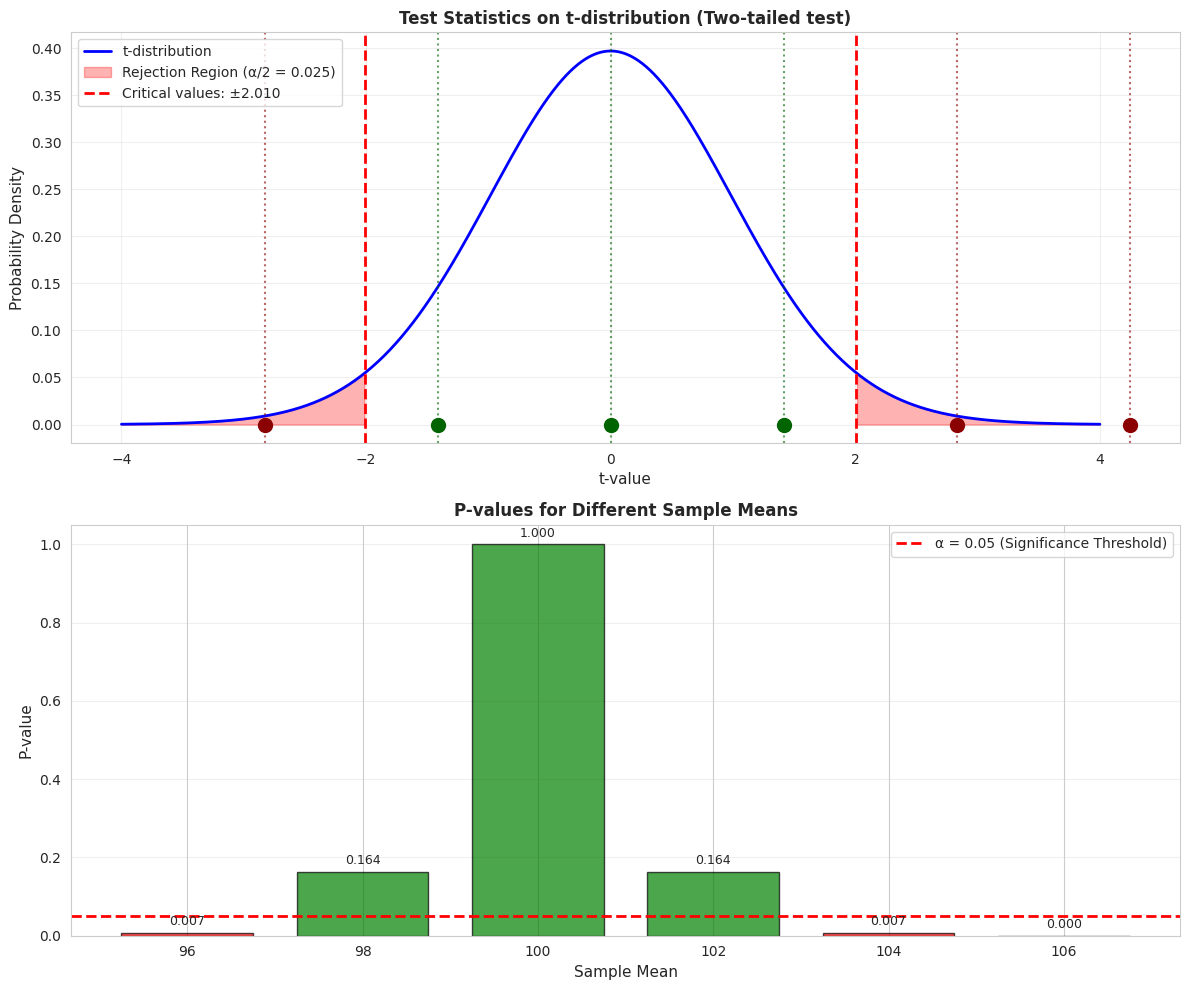


KEY OBSERVATIONS:
----------------------------------------------------------------------
1. Sample means far from 100 (e.g., 96, 106):
   - Large |t-statistic|
   - Small p-value (< 0.05)
   - REJECT H₀ (statistically significant)

2. Sample means close to 100 (e.g., 98, 102):
   - Small |t-statistic|
   - Large p-value (> 0.05)
   - FAIL TO REJECT H₀ (not statistically significant)

3. The p-value tells us:
   - How 'surprising' our sample result is
   - IF H₀ were true
   - Small p-value = strong evidence against H₀


In [ ]:
# Interactive P-value Explorer

print("="*70)
print("UNDERSTANDING P-VALUES AND SIGNIFICANCE")
print("="*70)
print()

# Scenario setup
mu_null = 100  # Hypothesized population mean (H₀: μ = 100)
sample_size = 50
alpha = 0.05

print("SCENARIO: Testing if population mean = 100")
print(f"  H₀: μ = {mu_null}")
print(f"  H₁: μ ≠ {mu_null} (two-tailed test)")
print(f"  Significance level: α = {alpha}")
print(f"  Sample size: n = {sample_size}")
print()

# Let's test different sample means
test_means = [96, 98, 100, 102, 104, 106]
results = []

print("Testing different sample means:")
print("-" * 70)

for x_bar in test_means:
    # Assume sample std = 10 for all (for comparison)
    s = 10

    # Calculate t-statistic
    t_stat = (x_bar - mu_null) / (s / np.sqrt(sample_size))

    # Calculate p-value (two-tailed)
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=sample_size-1))

    # Decision
    decision = "REJECT H₀" if p_value < alpha else "FAIL TO REJECT H₀"
    significant = "YES" if p_value < alpha else "NO"

    results.append({
        'mean': x_bar,
        't_stat': t_stat,
        'p_value': p_value,
        'significant': significant,
        'decision': decision
    })

    print(f"Sample mean = {x_bar:3d}: t = {t_stat:6.3f}, p = {p_value:.4f}, "
          f"Significant: {significant:3s}, {decision}")

print("=" * 70)

# Visualize the relationship
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Top plot: t-distribution with critical regions
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df=sample_size-1)

# Critical values for two-tailed test
t_crit = stats.t.ppf(1 - alpha/2, df=sample_size-1)

ax1.plot(x, y, 'b-', linewidth=2, label='t-distribution')
ax1.fill_between(x, y, where=(x <= -t_crit), alpha=0.3, color='red',
                label=f'Rejection Region (α/2 = {alpha/2})')
ax1.fill_between(x, y, where=(x >= t_crit), alpha=0.3, color='red')
ax1.axvline(-t_crit, color='red', linestyle='--', linewidth=2,
           label=f'Critical values: ±{t_crit:.3f}')
ax1.axvline(t_crit, color='red', linestyle='--', linewidth=2)

# Plot test statistics
for result in results:
    color = 'darkred' if result['significant'] == 'YES' else 'darkgreen'
    ax1.axvline(result['t_stat'], color=color, alpha=0.6, linestyle=':')
    ax1.plot(result['t_stat'], 0, 'o', color=color, markersize=10)

ax1.set_xlabel('t-value', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('Test Statistics on t-distribution (Two-tailed test)',
             fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bottom plot: P-values vs Sample Means
means = [r['mean'] for r in results]
p_values = [r['p_value'] for r in results]
colors_bar = ['red' if r['significant'] == 'YES' else 'green' for r in results]

ax2.bar(means, p_values, color=colors_bar, edgecolor='black', alpha=0.7, width=1.5)
ax2.axhline(alpha, color='red', linestyle='--', linewidth=2,
           label=f'α = {alpha} (Significance Threshold)')
ax2.set_xlabel('Sample Mean', fontsize=11)
ax2.set_ylabel('P-value', fontsize=11)
ax2.set_title('P-values for Different Sample Means', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add text annotations
for mean, p in zip(means, p_values):
    ax2.text(mean, p + 0.02, f'{p:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print()
print("KEY OBSERVATIONS:")
print("-" * 70)
print("1. Sample means far from 100 (e.g., 96, 106):")
print("   - Large |t-statistic|")
print("   - Small p-value (< 0.05)")
print("   - REJECT H₀ (statistically significant)")
print()
print("2. Sample means close to 100 (e.g., 98, 102):")
print("   - Small |t-statistic|")
print("   - Large p-value (> 0.05)")
print("   - FAIL TO REJECT H₀ (not statistically significant)")
print()
print("3. The p-value tells us:")
print("   - How 'surprising' our sample result is")
print("   - IF H₀ were true")
print("   - Small p-value = strong evidence against H₀")
print("=" * 70)

UNDERSTANDING TYPE I AND TYPE II ERRORS

Scenario: Testing H₀: μ = 50 vs H₁: μ > 50
True population mean (unknown): μ = 52
Sample size: n = 30
Significance level: α = 0.05
Critical sample mean: 51.50

Type I Error (α):  0.050 (5.0%)
  - Probability of rejecting H₀ when it's true

Type II Error (β): 0.293 (29.3%)
  - Probability of failing to reject H₀ when it's false

Power (1 - β):     0.707 (70.7%)
  - Probability of correctly rejecting false H₀



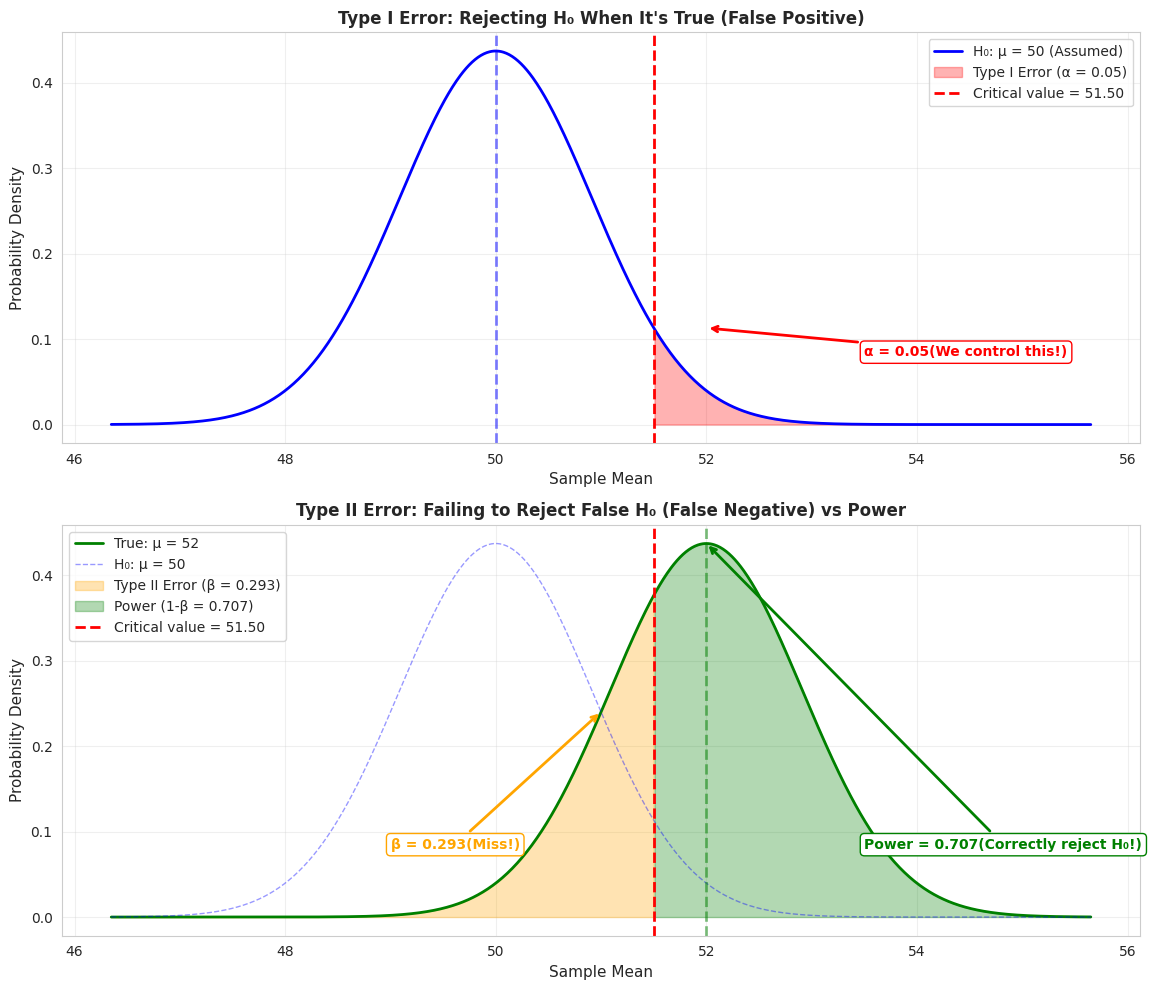


INTERPRETATION:
----------------------------------------------------------------------
1. If we set α = 0.05, we have a 5.0% chance of Type I error
   (false alarm - rejecting true H₀)

2. With true mean = 52, we have β = 0.293 chance of Type II error
   (miss - failing to reject false H₀)

3. Power = 0.707 means 70.7% chance of correctly detecting
   the difference when it truly exists

TRADE-OFFS:
----------------------------------------------------------------------
- Decreasing α (being more conservative)
  → Reduces Type I error
  → BUT increases Type II error (lower power)

- Increasing sample size
  → Reduces BOTH error types
  → Increases power
  → This is why larger samples are better!


In [ ]:
# Visualizing Type I and Type II Errors

print("="*70)
print("UNDERSTANDING TYPE I AND TYPE II ERRORS")
print("="*70)
print()

# Scenario parameters
mu_null = 50  # Null hypothesis mean
mu_true = 52  # True population mean (unknown in practice)
sigma = 5     # Population standard deviation
n = 30        # Sample size
alpha = 0.05  # Significance level

# Standard error
se = sigma / np.sqrt(n)

# Critical value (for one-tailed test, μ > 50)
z_critical = stats.norm.ppf(1 - alpha)
x_critical = mu_null + z_critical * se

print(f"Scenario: Testing H₀: μ = {mu_null} vs H₁: μ > {mu_null}")
print(f"True population mean (unknown): μ = {mu_true}")
print(f"Sample size: n = {n}")
print(f"Significance level: α = {alpha}")
print(f"Critical sample mean: {x_critical:.2f}")
print()

# Calculate Type II error probability (β)
z_beta = (x_critical - mu_true) / se
beta = stats.norm.cdf(z_beta)
power = 1 - beta

print(f"Type I Error (α):  {alpha:.3f} ({alpha*100:.1f}%)")
print(f"  - Probability of rejecting H₀ when it's true")
print()
print(f"Type II Error (β): {beta:.3f} ({beta*100:.1f}%)")
print(f"  - Probability of failing to reject H₀ when it's false")
print()
print(f"Power (1 - β):     {power:.3f} ({power*100:.1f}%)")
print(f"  - Probability of correctly rejecting false H₀")
print()

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Prepare distributions
x_range = np.linspace(mu_null - 4*se, mu_true + 4*se, 1000)
y_null = stats.norm.pdf(x_range, mu_null, se)
y_true = stats.norm.pdf(x_range, mu_true, se)

# Top plot: Type I Error (α)
ax1.plot(x_range, y_null, 'b-', linewidth=2, label=f'H₀: μ = {mu_null} (Assumed)')
ax1.fill_between(x_range, y_null, where=(x_range >= x_critical),
                alpha=0.3, color='red', label=f'Type I Error (α = {alpha})')
ax1.axvline(x_critical, color='red', linestyle='--', linewidth=2,
           label=f'Critical value = {x_critical:.2f}')
ax1.axvline(mu_null, color='blue', linestyle='--', linewidth=2, alpha=0.5)

ax1.set_xlabel('Sample Mean', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title("Type I Error: Rejecting H₀ When It's True (False Positive)", fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add annotation
ax1.annotate(f'α = {alpha}(We control this!)',
            xy=(x_critical + 0.5, stats.norm.pdf(x_critical, mu_null, se)),
            xytext=(x_critical + 2, 0.08),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='red'))

# Bottom plot: Type II Error (β) and Power
ax2.plot(x_range, y_true, 'g-', linewidth=2, label=f'True: μ = {mu_true}')
ax2.plot(x_range, y_null, 'b--', linewidth=1, alpha=0.4, label=f'H₀: μ = {mu_null}')

ax2.fill_between(x_range, y_true, where=(x_range < x_critical),
                alpha=0.3, color='orange', label=f'Type II Error (β = {beta:.3f})')
ax2.fill_between(x_range, y_true, where=(x_range >= x_critical),
                alpha=0.3, color='green', label=f'Power (1-β = {power:.3f})')
ax2.axvline(x_critical, color='red', linestyle='--', linewidth=2,
           label=f'Critical value = {x_critical:.2f}')
ax2.axvline(mu_true, color='green', linestyle='--', linewidth=2, alpha=0.5)

ax2.set_xlabel('Sample Mean', fontsize=11)
ax2.set_ylabel('Probability Density', fontsize=11)
ax2.set_title('Type II Error: Failing to Reject False H₀ (False Negative) vs Power',
             fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Add annotations
ax2.annotate(f'β = {beta:.3f}(Miss!)',
            xy=(x_critical - 0.5, stats.norm.pdf(x_critical - 0.5, mu_true, se)),
            xytext=(x_critical - 2.5, 0.08),
            arrowprops=dict(arrowstyle='->', color='orange', lw=2),
            fontsize=10, color='orange', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='orange'))

ax2.annotate(f'Power = {power:.3f}(Correctly reject H₀!)',
            xy=(x_critical + 0.5, stats.norm.pdf(x_critical + 0.5, mu_true, se)),
            xytext=(x_critical + 2, 0.08),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=10, color='green', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='green'))

plt.tight_layout()
plt.show()

print()
print("INTERPRETATION:")
print("-" * 70)
print(f"1. If we set α = {alpha}, we have a {alpha*100}% chance of Type I error")
print(f"   (false alarm - rejecting true H₀)")
print()
print(f"2. With true mean = {mu_true}, we have β = {beta:.3f} chance of Type II error")
print(f"   (miss - failing to reject false H₀)")
print()
print(f"3. Power = {power:.3f} means {power*100:.1f}% chance of correctly detecting")
print(f"   the difference when it truly exists")
print()
print("TRADE-OFFS:")
print("-" * 70)
print("- Decreasing α (being more conservative)")
print("  → Reduces Type I error")
print("  → BUT increases Type II error (lower power)")
print()
print("- Increasing sample size")
print("  → Reduces BOTH error types")
print("  → Increases power")
print("  → This is why larger samples are better!")
print("=" * 70)

### 🔍 TO DO #6: Understanding P-values and Errors

**Part A: P-value Interpretation**

For each p-value below, state whether you would reject or fail to reject H₀ at α = 0.05, and interpret what it means:

1. p-value = 0.001
2. p-value = 0.049
3. p-value = 0.051
4. p-value = 0.250

**Part B: Error Scenarios**

Identify whether each scenario describes a Type I error, Type II error, or correct decision:

1. A quality control test rejects a batch of products as defective when they actually meet specifications
2. A medical test fails to detect a disease that is present
3. A hypothesis test correctly rejects a false null hypothesis
4. A court finds a defendant not guilty when they are actually innocent

**Part C: Interactive Exploration**

Modify the "Understanding Type I and Type II Errors" code above:

1. Change α from 0.05 to 0.01 (more conservative)
   - What happens to Type I error?
   - What happens to Type II error and power?

2. Change sample size from 30 to 100
   - How does this affect β?
   - How does this affect power?

3. Change true mean from 52 to 54 (larger effect size)
   - How does this affect power?
   - Why is it easier to detect larger differences?

**Part D: Critical Thinking**

Answer these questions:

1. Why don't we just set α = 0.001 to minimize Type I error?
2. If you're testing a new drug's effectiveness, which error type is more serious and why?
3. A researcher reports: "My p-value is 0.06, which is almost significant." Is this valid reasoning?

---

---

## Section 7: One-Sample Tests (Z-test and T-test)

### Choosing Between Z-test and T-test

The decision is straightforward:

| **Condition** | **Test to Use** |
|--------------|----------------|
| σ (population std dev) is **known** | **Z-test** |
| σ is **unknown** (use sample s) | **T-test** |
| Large sample (n > 30) AND σ unknown | **T-test** (Z also works but T is safer) |

**In practice:** Almost always use T-test because σ is rarely known!

### One-Sample Z-test

**When to use:** Population σ is known (rare in practice)

**Test Statistic:**
$$Z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}$$

**Decision Rule:**
- Compare Z to critical value from standard normal table
- Or: Compare p-value to α

### One-Sample T-test

**When to use:** Population σ is unknown (common in practice)

**Test Statistic:**
$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}$$

**Decision Rule:**
- Compare t to critical value from t-distribution with df = n-1
- Or: Compare p-value to α

### The Complete Testing Process

1. **State Hypotheses**
   - H₀: μ = μ₀ (or ≤, ≥)
   - H₁: μ ≠ μ₀ (or <, >)

2. **Set Significance Level**
   - Usually α = 0.05

3. **Calculate Test Statistic**
   - Z or t, depending on whether σ is known

4. **Find P-value**
   - Probability of observing such extreme results

5. **Make Decision**
   - If p-value < α: Reject H₀
   - If p-value ≥ α: Fail to reject H₀

6. **Interpret in Context**
   - State conclusion in plain language

---

EXAMPLE 1: ONE-SAMPLE Z-TEST

SCENARIO: Cereal Box Weight Quality Control
----------------------------------------------------------------------
A cereal manufacturer claims boxes weigh 500g on average.
The filling machine's variability is well-known: σ = 15g.
A quality inspector suspects the boxes are being UNDERFILLED.
She samples 40 boxes to test this claim.

DATA:
  Claimed population mean (μ₀): 500g
  Known population std dev (σ): 15g
  Sample size (n): 40 boxes
  Sample mean (x̄): 491.72g

STEP 1: State Hypotheses
----------------------------------------------------------------------
  H₀: μ ≥ 500g  (Boxes are NOT underfilled)
  H₁: μ < 500g  (Boxes ARE underfilled) ← What we suspect
  Type: One-tailed (left-tailed) test

STEP 2: Set Significance Level: α = 0.05

STEP 3: Calculate Z-statistic
  Standard Error: SE = σ/√n = 15/√40 = 2.372
  Z = (x̄ - μ₀) / SE
  Z = (491.72 - 500) / 2.372
  Z = -3.491

STEP 4: Calculate P-value
  For left-tailed test: p-value = P(Z ≤ -3.491)
  p-val

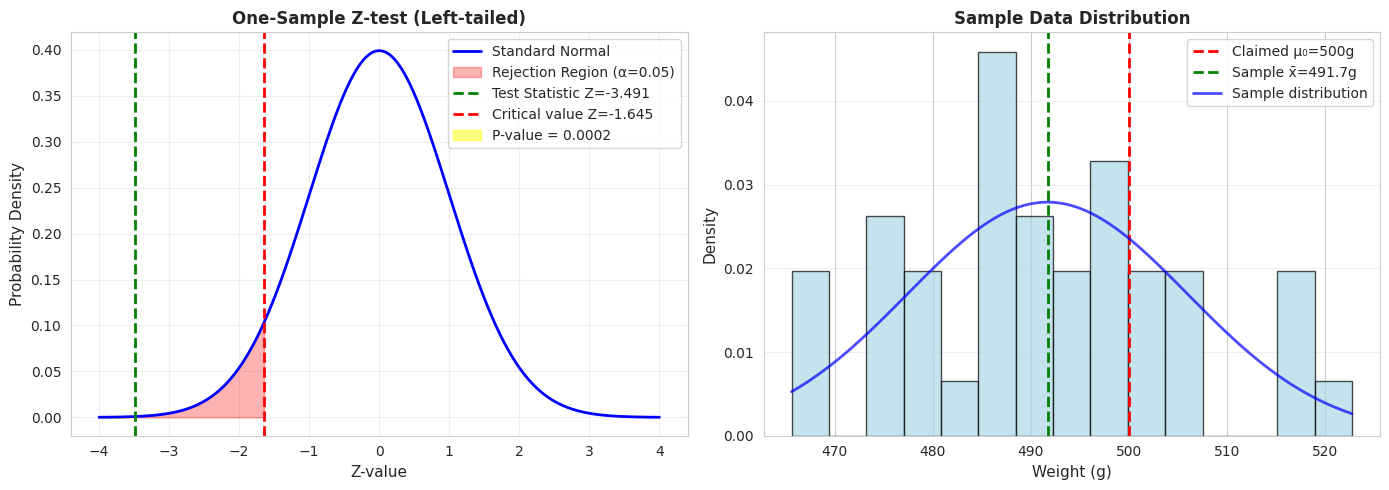

In [ ]:
# Example 1: Z-test (σ known) - Manufacturing Quality Control

print("="*70)
print("EXAMPLE 1: ONE-SAMPLE Z-TEST")
print("="*70)
print()

# Scenario
print("SCENARIO: Cereal Box Weight Quality Control")
print("-" * 70)
print("A cereal manufacturer claims boxes weigh 500g on average.")
print("The filling machine's variability is well-known: σ = 15g.")
print("A quality inspector suspects the boxes are being UNDERFILLED.")
print("She samples 40 boxes to test this claim.")
print()

# Given data
mu_claimed = 500  # Claimed mean
sigma_known = 15  # Known population std dev (from machine specs)
n = 40
alpha = 0.05

# Simulate sample data (true mean is 495g - slightly underfilled)
np.random.seed(42)
sample_weights = np.random.normal(loc=495, scale=sigma_known, size=n)
x_bar = np.mean(sample_weights)

print("DATA:")
print(f"  Claimed population mean (μ₀): {mu_claimed}g")
print(f"  Known population std dev (σ): {sigma_known}g")
print(f"  Sample size (n): {n} boxes")
print(f"  Sample mean (x̄): {x_bar:.2f}g")
print()

# STEP 1: State hypotheses
print("STEP 1: State Hypotheses")
print("-" * 70)
print("  H₀: μ ≥ 500g  (Boxes are NOT underfilled)")
print("  H₁: μ < 500g  (Boxes ARE underfilled) ← What we suspect")
print("  Type: One-tailed (left-tailed) test")
print()

# STEP 2: Set significance level
print(f"STEP 2: Set Significance Level: α = {alpha}")
print()

# STEP 3: Calculate test statistic
se = sigma_known / np.sqrt(n)
z_statistic = (x_bar - mu_claimed) / se

print("STEP 3: Calculate Z-statistic")
print(f"  Standard Error: SE = σ/√n = {sigma_known}/√{n} = {se:.3f}")
print(f"  Z = (x̄ - μ₀) / SE")
print(f"  Z = ({x_bar:.2f} - {mu_claimed}) / {se:.3f}")
print(f"  Z = {z_statistic:.3f}")
print()

# STEP 4: Calculate p-value
p_value = stats.norm.cdf(z_statistic)  # Left-tailed

print("STEP 4: Calculate P-value")
print(f"  For left-tailed test: p-value = P(Z ≤ {z_statistic:.3f})")
print(f"  p-value = {p_value:.4f}")
print()

# STEP 5: Make decision
print("STEP 5: Make Decision")
print("-" * 70)
print(f"  Decision Rule: Reject H₀ if p-value < α")
print(f"  {p_value:.4f} {'<' if p_value < alpha else '≥'} {alpha}")

if p_value < alpha:
    decision = "REJECT H₀"
    conclusion = "SIGNIFICANT: Evidence suggests boxes are underfilled"
else:
    decision = "FAIL TO REJECT H₀"
    conclusion = "NOT SIGNIFICANT: Insufficient evidence of underfilling"

print(f"  Decision: {decision}")
print()

# STEP 6: Interpret
print("STEP 6: Interpretation")
print("-" * 70)
print(f"  {conclusion}")
print(f"  At α = {alpha} significance level, the sample data")
if p_value < alpha:
    print(f"  provides sufficient evidence that the true mean weight")
    print(f"  is less than the claimed 500g.")
else:
    print(f"  does not provide sufficient evidence that the boxes")
    print(f"  are underfilled.")
print("=" * 70)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Standard normal distribution with test statistic
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

z_critical = stats.norm.ppf(alpha)

ax1.plot(x, y, 'b-', linewidth=2, label='Standard Normal')
ax1.fill_between(x, y, where=(x <= z_critical), alpha=0.3, color='red',
                label=f'Rejection Region (α={alpha})')
ax1.axvline(z_statistic, color='green', linestyle='--', linewidth=2,
           label=f'Test Statistic Z={z_statistic:.3f}')
ax1.axvline(z_critical, color='red', linestyle='--', linewidth=2,
           label=f'Critical value Z={z_critical:.3f}')

# Shade p-value area
ax1.fill_between(x, y, where=(x <= z_statistic), alpha=0.5, color='yellow',
                label=f'P-value = {p_value:.4f}')

ax1.set_xlabel('Z-value', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('One-Sample Z-test (Left-tailed)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Sample distribution
ax2.hist(sample_weights, bins=15, color='lightblue', edgecolor='black', alpha=0.7, density=True)
ax2.axvline(mu_claimed, color='red', linestyle='--', linewidth=2, label=f'Claimed μ₀={mu_claimed}g')
ax2.axvline(x_bar, color='green', linestyle='--', linewidth=2, label=f'Sample x̄={x_bar:.1f}g')

# Add normal curve overlay
x_range = np.linspace(min(sample_weights), max(sample_weights), 100)
ax2.plot(x_range, stats.norm.pdf(x_range, x_bar, np.std(sample_weights, ddof=1)),
        'b-', linewidth=2, alpha=0.7, label='Sample distribution')

ax2.set_xlabel('Weight (g)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Sample Data Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


EXAMPLE 2: ONE-SAMPLE T-TEST

SCENARIO: Pizza Delivery Time
----------------------------------------------------------------------
A pizza shop claims average delivery time is 30 minutes or less.
We suspect deliveries actually take LONGER than 30 minutes.
We don't know the population standard deviation.

DATA:
  Claimed mean (μ₀): 30 minutes
  Sample size (n): 16 deliveries
  Sample mean (x̄): 32.66 minutes
  Sample std dev (s): 2.43 minutes
  Degrees of freedom (df): 15

STEP 1: State Hypotheses
----------------------------------------------------------------------
  H₀: μ ≤ 30 minutes  (Shop's claim is correct)
  H₁: μ > 30 minutes  (Takes longer than claimed) ← What we suspect
  Type: One-tailed (right-tailed) test

STEP 2: Set Significance Level: α = 0.05

STEP 3: Calculate T-statistic
  Standard Error: SE = s/√n = 2.43/√16 = 0.607
  t = (x̄ - μ₀) / SE
  t = (32.66 - 30) / 0.607
  t = 4.375

STEP 4: Calculate P-value
  For right-tailed test: p-value = P(t ≥ 4.375)
  with df = 15
 

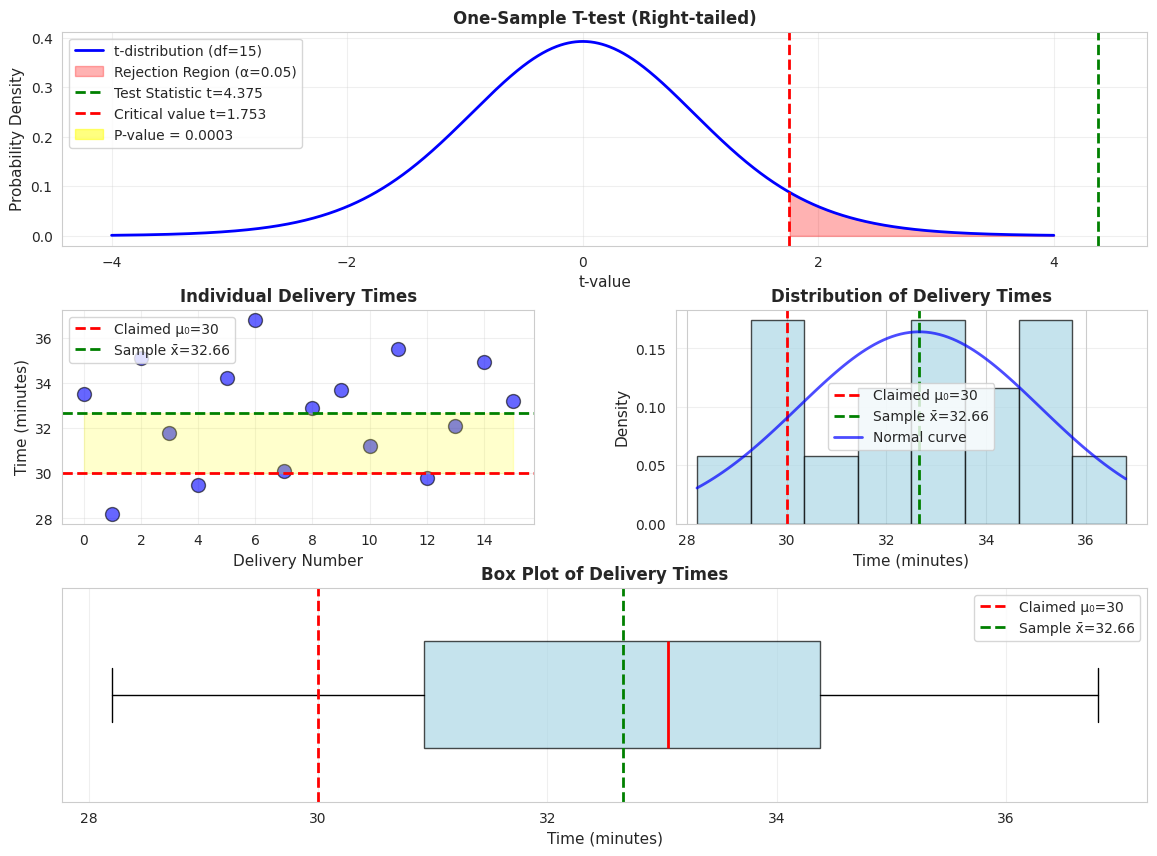

In [ ]:
# Example 2: T-test (σ unknown) - Pizza Delivery Time

print("\n" + "="*70)
print("EXAMPLE 2: ONE-SAMPLE T-TEST")
print("="*70)
print()

# Scenario
print("SCENARIO: Pizza Delivery Time")
print("-" * 70)
print("A pizza shop claims average delivery time is 30 minutes or less.")
print("We suspect deliveries actually take LONGER than 30 minutes.")
print("We don't know the population standard deviation.")
print()

# Sample data: delivery times in minutes
delivery_times = np.array([33.5, 28.2, 35.1, 31.8, 29.5, 34.2, 36.8, 30.1,
                          32.9, 33.7, 31.2, 35.5, 29.8, 32.1, 34.9, 33.2])

n = len(delivery_times)
x_bar = np.mean(delivery_times)
s = np.std(delivery_times, ddof=1)
mu_claimed = 30
alpha = 0.05
df = n - 1

print("DATA:")
print(f"  Claimed mean (μ₀): {mu_claimed} minutes")
print(f"  Sample size (n): {n} deliveries")
print(f"  Sample mean (x̄): {x_bar:.2f} minutes")
print(f"  Sample std dev (s): {s:.2f} minutes")
print(f"  Degrees of freedom (df): {df}")
print()

# STEP 1: State hypotheses
print("STEP 1: State Hypotheses")
print("-" * 70)
print("  H₀: μ ≤ 30 minutes  (Shop's claim is correct)")
print("  H₁: μ > 30 minutes  (Takes longer than claimed) ← What we suspect")
print("  Type: One-tailed (right-tailed) test")
print()

# STEP 2: Set significance level
print(f"STEP 2: Set Significance Level: α = {alpha}")
print()

# STEP 3: Calculate test statistic
se = s / np.sqrt(n)
t_statistic = (x_bar - mu_claimed) / se

print("STEP 3: Calculate T-statistic")
print(f"  Standard Error: SE = s/√n = {s:.2f}/√{n} = {se:.3f}")
print(f"  t = (x̄ - μ₀) / SE")
print(f"  t = ({x_bar:.2f} - {mu_claimed}) / {se:.3f}")
print(f"  t = {t_statistic:.3f}")
print()

# STEP 4: Calculate p-value
p_value = 1 - stats.t.cdf(t_statistic, df)  # Right-tailed

print("STEP 4: Calculate P-value")
print(f"  For right-tailed test: p-value = P(t ≥ {t_statistic:.3f})")
print(f"  with df = {df}")
print(f"  p-value = {p_value:.4f}")
print()

# Also find critical t-value for reference
t_critical = stats.t.ppf(1 - alpha, df)
print(f"  Critical t-value at α={alpha}: {t_critical:.3f}")
print(f"  (For reference: Reject H₀ if t > {t_critical:.3f})")
print()

# STEP 5: Make decision
print("STEP 5: Make Decision")
print("-" * 70)
print(f"  Decision Rule: Reject H₀ if p-value < α")
print(f"  {p_value:.4f} {'<' if p_value < alpha else '≥'} {alpha}")

if p_value < alpha:
    decision = "REJECT H₀"
    conclusion = "SIGNIFICANT: Evidence suggests delivery takes longer than claimed"
else:
    decision = "FAIL TO REJECT H₀"
    conclusion = "NOT SIGNIFICANT: Insufficient evidence that delivery takes longer"

print(f"  Decision: {decision}")
print()

# STEP 6: Interpret
print("STEP 6: Interpretation")
print("-" * 70)
print(f"  {conclusion}")
print(f"  At α = {alpha} significance level,")
if p_value < alpha:
    print(f"  we have sufficient evidence that the true average")
    print(f"  delivery time exceeds the claimed 30 minutes.")
    print(f"  The sample average of {x_bar:.2f} minutes is")
    print(f"  statistically significantly different from 30 minutes.")
else:
    print(f"  we don't have sufficient evidence to conclude")
    print(f"  that deliveries take longer than 30 minutes.")
print("=" * 70)

# Verify using scipy
t_stat_scipy, p_val_scipy = stats.ttest_1samp(delivery_times, mu_claimed, alternative='greater')
print(f"\nVerification using scipy.stats.ttest_1samp:")
print(f"  t-statistic: {t_stat_scipy:.3f}")
print(f"  p-value: {p_val_scipy:.4f}")

# Visualization
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Plot 1: t-distribution with test statistic
ax1 = fig.add_subplot(gs[0, :])
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

ax1.plot(x, y, 'b-', linewidth=2, label=f't-distribution (df={df})')
ax1.fill_between(x, y, where=(x >= t_critical), alpha=0.3, color='red',
                label=f'Rejection Region (α={alpha})')
ax1.axvline(t_statistic, color='green', linestyle='--', linewidth=2,
           label=f'Test Statistic t={t_statistic:.3f}')
ax1.axvline(t_critical, color='red', linestyle='--', linewidth=2,
           label=f'Critical value t={t_critical:.3f}')

# Shade p-value area
ax1.fill_between(x, y, where=(x >= t_statistic), alpha=0.5, color='yellow',
                label=f'P-value = {p_value:.4f}')

ax1.set_xlabel('t-value', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.set_title('One-Sample T-test (Right-tailed)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Raw data points
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(range(n), delivery_times, color='blue', s=100, alpha=0.6, edgecolor='black')
ax2.axhline(mu_claimed, color='red', linestyle='--', linewidth=2, label=f'Claimed μ₀={mu_claimed}')
ax2.axhline(x_bar, color='green', linestyle='--', linewidth=2, label=f'Sample x̄={x_bar:.2f}')
ax2.fill_between(range(n), mu_claimed, x_bar, alpha=0.2, color='yellow')
ax2.set_xlabel('Delivery Number', fontsize=11)
ax2.set_ylabel('Time (minutes)', fontsize=11)
ax2.set_title('Individual Delivery Times', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Histogram
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(delivery_times, bins=8, color='lightblue', edgecolor='black', alpha=0.7, density=True)
ax3.axvline(mu_claimed, color='red', linestyle='--', linewidth=2, label=f'Claimed μ₀={mu_claimed}')
ax3.axvline(x_bar, color='green', linestyle='--', linewidth=2, label=f'Sample x̄={x_bar:.2f}')

# Overlay normal curve
x_range = np.linspace(min(delivery_times), max(delivery_times), 100)
ax3.plot(x_range, stats.norm.pdf(x_range, x_bar, s),
        'b-', linewidth=2, alpha=0.7, label='Normal curve')

ax3.set_xlabel('Time (minutes)', fontsize=11)
ax3.set_ylabel('Density', fontsize=11)
ax3.set_title('Distribution of Delivery Times', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Box plot
ax4 = fig.add_subplot(gs[2, :])
bp = ax4.boxplot([delivery_times], vert=False, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2),
                 widths=0.5)
ax4.axvline(mu_claimed, color='red', linestyle='--', linewidth=2, label=f'Claimed μ₀={mu_claimed}')
ax4.axvline(x_bar, color='green', linestyle='--', linewidth=2, label=f'Sample x̄={x_bar:.2f}')
ax4.set_xlabel('Time (minutes)', fontsize=11)
ax4.set_title('Box Plot of Delivery Times', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='x')
ax4.set_yticks([])

plt.show()

### 🔍 TO DO #7: Conduct Your Own Hypothesis Tests

**Part A: Practice Z-test**

A light bulb manufacturer claims their bulbs last an average of 1000 hours. The population standard deviation is known to be σ = 120 hours from years of production data. You test 50 bulbs and find x̄ = 970 hours.

Tasks:
1. State H₀ and H₁ (test if bulbs last LESS than claimed)
2. Calculate the Z-statistic
3. Find the p-value
4. Make a decision at α = 0.05
5. Interpret your result

**Part B: Practice T-test**

A teacher claims that students in her class study an average of 10 hours per week. You survey 25 students and get these results:
```python
study_hours = np.array([8, 12, 9, 11, 7, 10, 13, 9, 11, 10,
                        8, 12, 9, 10, 11, 8, 10, 12, 9, 11,
                        10, 8, 11, 9, 10])
```

Tasks:
1. State H₀ and H₁ (test if study time is DIFFERENT from 10 hours)
2. Calculate x̄ and s
3. Calculate the t-statistic
4. Find the p-value (two-tailed test!)
5. Make a decision at α = 0.05
6. Create visualizations showing your data and decision

**Part C: Compare Z vs T**

Generate a sample of size 20 from a normal distribution with mean=50 and std=10:
```python
sample = np.random.normal(50, 10, 20)
```

1. Test H₀: μ = 50 vs H₁: μ ≠ 50 using:
   - Z-test (assuming σ = 10 is known)
   - T-test (using sample s)
2. Compare the test statistics and p-values
3. Which test is more conservative (gives larger p-value)?
4. Repeat with n = 100. How do the tests compare now?

---

---

## Section 8: Summary and Key Formulas

### What We Learned in This Module

Congratulations! You've mastered the foundations of estimation and hypothesis testing. Here's what you now know:

#### 1. Confidence Intervals
- **Purpose:** Provide a range of plausible values for a population parameter
- **Interpretation:** "We are X% confident that the true parameter lies in this interval"
- **Z-interval (σ known):** $\bar{x} \pm Z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$
- **T-interval (σ unknown):** $\bar{x} \pm t_{\alpha/2,df} \cdot \frac{s}{\sqrt{n}}$

#### 2. Sample Size Determination
- **Formula:** $n = \left(\frac{Z_{\alpha/2} \cdot \sigma}{E}\right)^2$
- **Key insight:** Halving margin of error requires 4× the sample size
- **Trade-offs:** Balance precision, confidence, and cost

#### 3. Hypothesis Testing Framework
- **Null Hypothesis (H₀):** Status quo, what we assume is true
- **Alternative Hypothesis (H₁):** What we want to prove
- **Four-step process:** State hypotheses → Set α → Calculate test statistic → Decide

#### 4. Errors and P-values
- **Type I Error (α):** False alarm - rejecting true H₀
- **Type II Error (β):** Miss - failing to reject false H₀
- **P-value:** Probability of observing data at least as extreme, assuming H₀ is true
- **Decision rule:** Reject H₀ if p-value < α

#### 5. One-Sample Tests
- **Z-test:** Use when σ is known
- **T-test:** Use when σ is unknown (most common)
- **Choice depends ONLY on:** whether population σ is known

---

### Essential Formulas Reference Card

```
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

CONFIDENCE INTERVALS

Z-interval (σ known):
    CI = x̄ ± Z(α/2) × (σ/√n)

T-interval (σ unknown):
    CI = x̄ ± t(α/2,df) × (s/√n)    where df = n - 1

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

SAMPLE SIZE

For mean estimation:
    n = [(Z(α/2) × σ) / E]²

Always round UP!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

HYPOTHESIS TESTS

Z-test statistic (σ known):
    Z = (x̄ - μ₀) / (σ/√n)

T-test statistic (σ unknown):
    t = (x̄ - μ₀) / (s/√n)    where df = n - 1

Decision Rule:
    IF p-value < α: Reject H₀
    ELSE: Fail to reject H₀

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

EFFECT SIZE

Cohen's d:
    d = (x̄ - μ₀) / s

Interpretation:
    |d| < 0.2: Negligible
    |d| < 0.5: Small
    |d| < 0.8: Medium
    |d| ≥ 0.8: Large

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
```

---

### Decision Trees for Practical Use

#### When to Use Which Test?

```
Is population standard deviation (σ) known?
│
├─ YES → Use Z-test
│         CI: x̄ ± Z(α/2) × (σ/√n)
│         Test: Z = (x̄ - μ₀) / (σ/√n)
│
└─ NO → Use T-test
          CI: x̄ ± t(α/2,df) × (s/√n)
          Test: t = (x̄ - μ₀) / (s/√n)
```

#### What Type of Test?

```
What is your alternative hypothesis (H₁)?
│
├─ μ ≠ μ₀ (different from)
│   → Two-tailed test
│   → Rejection regions in both tails
│
├─ μ > μ₀ (greater than)
│   → Right-tailed test
│   → Rejection region in right tail only
│
└─ μ < μ₀ (less than)
    → Left-tailed test
    → Rejection region in left tail only
```

---

## Section 9: Practice Problems

Test your understanding with these comprehensive problems!

---

### Problem Set A: Confidence Intervals

**Problem A1:** Battery Life
A sample of 25 smartphone batteries has a mean life of 850 hours with a standard deviation of 120 hours.
- Calculate a 90% confidence interval for the true mean battery life
- Interpret your result
- If you wanted the margin of error to be only 20 hours, what sample size would you need?

**Problem A2:** Comparing Intervals
Generate two samples:
```python
sample_small = np.random.normal(50, 10, 15)
sample_large = np.random.normal(50, 10, 100)
```
- Calculate 95% CI for both samples
- Which is wider? Why?
- How does sample size affect precision?

---

### Problem Set B: Sample Size Determination

**Problem B1:** Marketing Survey
You want to estimate average customer satisfaction (scale 1-10) within ±0.5 points with 95% confidence. Past data suggests σ ≈ 2.5.
- Calculate required sample size
- What if you want 99% confidence instead?
- What if you only need ±1 point precision?

**Problem B2:** Budget Constraints
You have budget for only 50 surveys, but need E = 0.3 with 95% confidence. What's the maximum σ you can handle?

---

### Problem Set C: Hypothesis Testing

**Problem C1:** Restaurant Wait Time
A restaurant claims average wait time is 15 minutes. You time 20 customers:
```python
wait_times = [18, 14, 16, 19, 15, 17, 20, 14, 16, 18,
              15, 19, 17, 16, 21, 15, 18, 16, 17, 19]
```
Test at α = 0.05 if wait times are LONGER than claimed.

**Problem C2:** Quality Control
A machine should produce bolts with mean diameter 10.0mm. Sample of 30 bolts has x̄ = 10.15mm, s = 0.25mm.
- Is the machine out of calibration? (test if μ ≠ 10.0)
- Calculate 95% CI
- Calculate Cohen's d

---

### Problem Set D: Comprehensive Analysis

**Problem D:** Drug Trial
A pharmaceutical company tests a new pain reliever. Current standard provides relief in 45 minutes on average. They test their new drug on 40 patients:

```python
relief_times = np.random.normal(loc=42, scale=8, size=40)
```

Complete a full analysis:
1. Descriptive statistics
2. 95% confidence interval
3. Hypothesis test (H₁: μ < 45, new drug is faster)
4. Effect size
5. Visualizations
6. Write a 1-paragraph conclusion

---

### Problem Set E: Critical Thinking

**Problem E1:** Interpretation
A researcher reports: "The 95% CI is (23.5, 28.1). This means there's a 95% probability the true mean is in this range." What's wrong with this interpretation?

**Problem E2:** Practical Significance vs Statistical Significance
A study finds that a new teaching method increases test scores by 0.5 points (on a 100-point scale), and this difference is statistically significant (p = 0.03). Should the school adopt the new method? Discuss.

**Problem E3:** Power and Sample Size
Why don't researchers always use very large samples to maximize power?

**Problem E4:** P-value Misunderstanding
Your colleague says: "My p-value is 0.06, so I'm 94% confident in my alternative hypothesis." Explain what's wrong and provide the correct interpretation.

---

## Additional Resources and Next Steps

### Mastering These Concepts

You've completed Week 3 on Estimation and Hypothesis Testing! Here's how to reinforce your learning:

**1. Practice with Real Data**
- Load datasets from your field of interest
- Conduct hypothesis tests on real problems
- Build confidence through repetition

**2. Key Concepts to Master**
- ✓ When to use Z vs T test
- ✓ How to interpret p-values correctly
- ✓ What confidence intervals really mean
- ✓ The relationship between CI and hypothesis tests
- ✓ Trade-offs in sample size planning

**3. Common Mistakes to Avoid**
- ❌ Saying "H₀ is true" instead of "fail to reject H₀"
- ❌ Interpreting p-value as probability H₀ is true
- ❌ Forgetting to check assumptions (normality for small samples)
- ❌ Confusing statistical and practical significance
- ❌ Using Z-test when σ is unknown

### Final Tips

**Remember:**
- Larger samples → More precision → More power
- Higher confidence → Wider intervals
- Smaller α → Lower Type I error but higher Type II error
- Always consider practical significance, not just statistical significance
- Visualize your data before testing
- Report effect sizes along with p-values

**Good Statistical Practice:**
1. State hypotheses clearly before collecting data
2. Choose α before seeing results
3. Check assumptions
4. Report confidence intervals
5. Discuss practical importance
6. Be transparent about limitations

---

### Congratulations!

You've completed a comprehensive introduction to estimation and hypothesis testing. These are the building blocks of statistical inference and will serve you well in research, data analysis, and decision-making.

**Keep practicing, stay curious, and happy analyzing!** 📊

---

## Appendix: Statistical Tables Reference

### Critical Values for Common Confidence Levels

#### Z-distribution (Standard Normal)

| Confidence Level | α | Z(α/2) |
|-----------------|---|--------|
| 90% | 0.10 | 1.645 |
| 95% | 0.05 | 1.960 |
| 98% | 0.02 | 2.326 |
| 99% | 0.01 | 2.576 |
| 99.9% | 0.001 | 3.291 |

#### T-distribution (Selected Values)

| df | 90% CI | 95% CI | 99% CI |
|----|--------|--------|--------|
| 5 | 2.015 | 2.571 | 4.032 |
| 10 | 1.812 | 2.228 | 3.169 |
| 15 | 1.753 | 2.131 | 2.947 |
| 20 | 1.725 | 2.086 | 2.845 |
| 25 | 1.708 | 2.060 | 2.787 |
| 30 | 1.697 | 2.042 | 2.750 |
| 50 | 1.676 | 2.009 | 2.678 |
| 100 | 1.660 | 1.984 | 2.626 |
| ∞ (Z) | 1.645 | 1.960 | 2.576 |

**Note:** For df > 30, t-distribution approaches normal distribution

---